In [1]:
%load_ext autoreload
%autoreload 2
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchmetrics.regression import R2Score
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# import glob
# import os
# from parametrizations import *
#from experiment_different_regions_thresholds import load_model
import pandas as pd
#import pickle
import xarray as xr
#from parametrizations import load_DYAMOND_data, load_grid
from data_utils import load_DYAMOND_data, load_grid, load_ds
# from training_gpu import get_dataloader, preprocess, preprocess_thresholded, get_standardized_ds
# Set device to gpu if avaible, else to cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
ds = xr.open_dataset('merged_15min_full_ICON-NWP-2km_DW-ATM_r1i1p1f1_2d_gn_20200120000000-20200301000000_R02B05.nc')

In [9]:
paths=['networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511173500_nonlinear_4d_corrected_00_timesteps_0.pkl',
'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511173532_nonlinear_4d_corrected_00_timesteps_0.pkl',
'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511173546_nonlinear_4d_corrected_00_timesteps_0.pkl',
'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511173635_nonlinear_4d_corrected_00_timesteps_0.pkl']
for path in paths:
    model = torch.load(path, map_location=device, weights_only=False)
    print(path)
    print(model['metadata']['val_loss'])

networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511173500_nonlinear_4d_corrected_00_timesteps_0.pkl
[0.1241563723196049, 0.12398368901698976, 0.1237266619387712, 0.12379633964920365, 0.12447613732033484, 0.12288981861560731, 0.12322379928182911, 0.12351965540466277, 0.12319144772164323, 0.12321695925567198, 0.13635586773523609, 0.1361489516315428, 0.13549048590196952, 0.13583771153176957, 0.135458584480189, 0.13505243481413737, 0.13654563863635868, 0.13514752883262732, 0.13671510119796604, 0.13528475090156536, 0.15147912674686975, 0.15013139073323045, 0.14925919707968002, 0.1515182118366162, 0.14827006798651482, 0.14830694903412628, 0.14713546506957048, 0.14754014164830248, 0.14826887815155917, 0.1472627744730562, 0.17323233696605478, 0.1749846137304391, 0.16965176243228572, 0.16395468462897198, 0.17341019917279482, 0.18254807320485514, 0.17367639076608854, 0.1744396751561823, 0.16926932825955252, 0.17373195291884863, 0.17421616650675

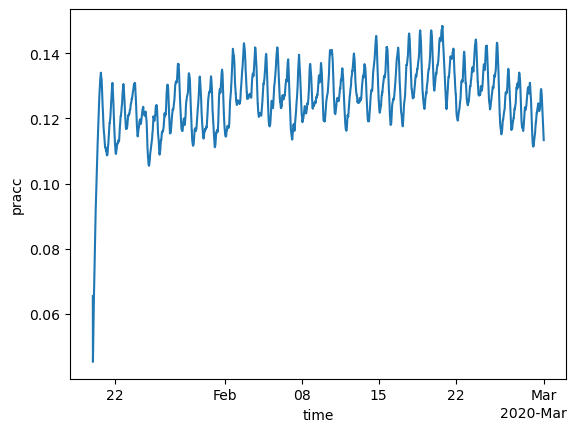

In [67]:
precip = ds.pracc.diff('time') * 4
precip.mean('cell').plot()

In [27]:
 # XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507130738_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')

XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=0.0.npy')
# XZ_val_base = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztest_NNbase_tp=0_wd=0.0.npy')

In [3]:
np.mean([0.78064166, 0.28824473, 0.52307145 ,0.40662081 ])

np.float64(0.4996446625)

In [23]:
Precip_True = XZ_val_base[:, 20:, 8]
Precip_base = XZ_val_base[:, 20:, 9]
R2Score()(torch.tensor(Precip_base.flatten()), torch.tensor(Precip_True.flatten())).item()

0.5216927528381348

In [24]:
Precip_True = XZ_val[:, :, 8]
Precip_org = XZ_val[:, :, 9]
R2Score()(torch.tensor(Precip_org.flatten()), torch.tensor(Precip_True.flatten())).item()

0.6659968495368958

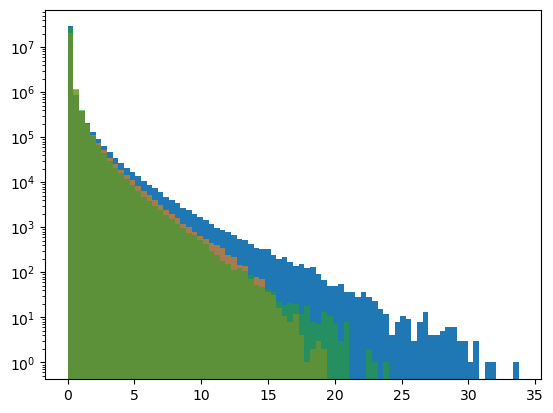

In [25]:
_, bins, _ =  plt.hist(Precip_True.flatten(), bins=80)
plt.hist(Precip_org.flatten(), bins=bins, alpha=0.6)
plt.hist(Precip_base.flatten(), bins=bins, alpha=0.6)
plt.yscale('log')
# plt.xlim(0, 35)

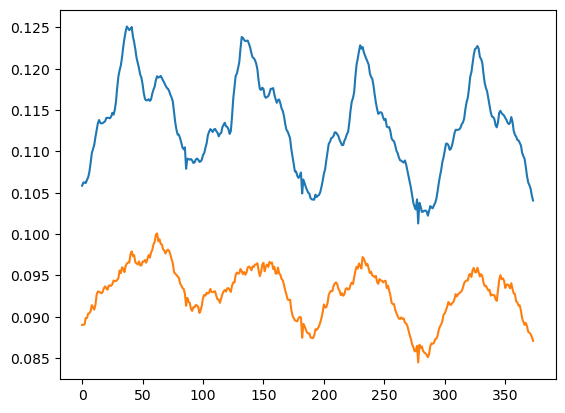

In [26]:
Precip_org.shape
plt.plot(np.mean(np.abs(Precip_base - Precip_True), axis=0))
plt.plot(np.mean(np.abs(Precip_org - Precip_True), axis=0))

(300.0, 400.0)

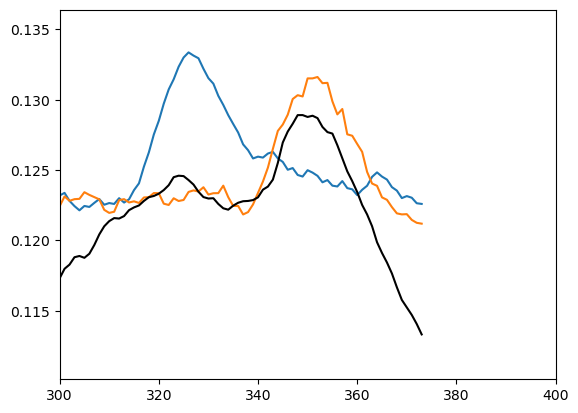

In [34]:
plt.plot(np.mean(Precip_base, axis=0))
plt.plot(np.mean(Precip_org, axis=0))
plt.plot(np.mean(Precip_True, axis=0), color='black')
t0 = 300
plt.xlim(t0, t0 + 100)

In [4]:
grid_path='/work/bd1179/b309297/DYAMOND_experiment/DYAMOND/icon_grid_0019_R02B05_G.nc'
ds_path='merged_15min_full_ICON-NWP-2km_DW-ATM_r1i1p1f1_2d_gn_20200120000000-20200301000000_R02B05.nc'
ext_par_path = '/work/pd1295/ICON/grids/public/mpim/0019/extpar.2016/r0001/icon_extpar_grid_0019_R02B05_G_20180829.nc'
grid = load_grid(grid_path)
ds = load_ds(ds_path)
ext_par = xr.open_dataset(ext_par_path)
ext_par = ext_par.assign_coords(
        clon=("cell", ds.clon.values),
        clat=("cell", ds.clat.values)
    )

# # Compute land_mask
# sea_land_frac = np.array([ext_par.FR_LAND_TOPO.values for _ in range(ds.time.shape[0])])
# ds = ds.assign({'is_land': (('time', 'cell'), sea_land_frac)})

### Load predicitions from pretrained NN

In [14]:
# Load data
ds = get_standardized_ds('global', 'ocean')
trainloader, valloader, _ = get_dataloader(ds, share_train=.8, share_val=.1, batch_size=1)

# Load pretrained model
# model_path = 'networks/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5, 6]_latent_dims=5_past_timesteps=10/20251202114915_global_ocean_threshold=0.0_kernel=3_alpha=0.5_lr=0.001_weigth_decay=1e-06.pkl'
# model = torch.load(model_path, weights_only=False, map_location=device)
# model = model.to(device)
# model.X = ds 
# model.X = model.X.to(device)

(8, 3897, 54702)


In [2]:
# Get ocean mask
grid = load_grid()
ocean_mask = grid.cell_sea_land_mask == -2
lon, lat = grid.clon.values[ocean_mask], grid.clat.values[ocean_mask]

### Compare precipitation histograms

In [5]:
# Load predicitions
def get_precip(path, precip_ind=8, rescale_precip=True, epsilon=None):
    data = np.load(path)
    coord = data[:, 0, 0].astype(int)
    precip = data[:, :, precip_ind]
    precip_pred = data[:, :, precip_ind + 1]

    if rescale_precip:
        precip_pred = np.exp(precip_pred) - epsilon
        precip = np.exp(precip) - epsilon
    precip[precip < 0] = 0.0
    precip_pred[precip_pred < 0] = 0.0
    return precip, precip_pred, coord

In [6]:
def precip_hist(precip_flatt, bins, density, alpha, label, color=None):
    precip_flatt = precip_flatt[precip_flatt > 0.0]
    precip_hist, bins = np.histogram(precip_flatt, density=density, bins=bins)
    plt.plot(bins[1:], precip_hist, alpha=alpha, label=label, color=color, linewidth=2)
    return precip_hist, bins

In [7]:
# from scipy.stats import cumfreq
def precip_amount(precip_flatt, bins, alpha, label, color=None, precip_threshold=None):
    # With KDE
    # kde = gaussian_kde(precip_flatt)

    # # 2. Create the x-axis range from 0 to 40
    # x_range = np.linspace(0, 40, 500)

    # # 3. Calculate PDF(x) and the product x * PDF(x)
    # pdf_values = kde.evaluate(x_range)
    # contribution = x_range * pdf_values

    # # 4. Plotting
    # plt.plot(x_range, contribution, label=r'$x \cdot PDF(x)$', color=color)

    # With histogram
    # if precip_threshold:
    #     precip_flatt = precip_flatt[precip_flatt <= precip_threshold]
    
    # precip_flatt = precip_flatt[precip_flatt > 0.0]
    # precip_amount, bins = np.histogram(precip_flatt, density=True, bins=bins)
    # # X = (bins[1:] - bins[:-1]) / 2 + bins[:-1]  # mid bin values
    # X = bins[1:]  # right bin values
    # precip_amount = precip_amount * X  #  X * PDF(X)
    # plt.plot(X, precip_amount, alpha=alpha, label=label, color=color)
    # return precip_amount, bins
    precip_flatt = precip_flatt[precip_flatt > 0.0]
    _, bins, _ = plt.hist(precip_flatt, bins=bins, density=False, alpha=alpha, label=label, color=color)

    return bins, _



In [ ]:
precip_org_ED_pred, precip_org_ED_True = np.load('20260417121500_Pr_combined_merged_val_test_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy')
precip_org_ED_pred = precip_org_ED_pred[:, -2*369: -369]
precip_org_ED_True = precip_org_ED_True[:, -2*369: -369]

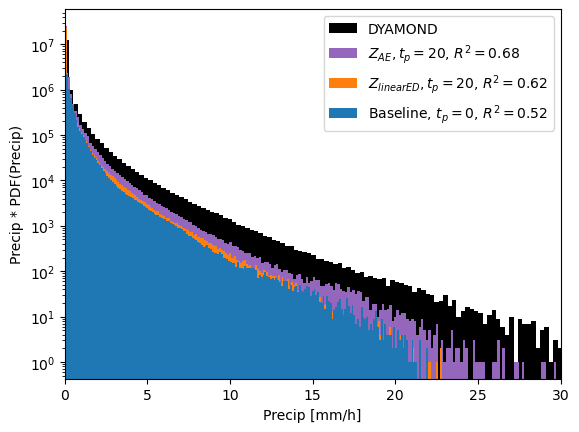

In [10]:
path_base = 'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20251209111425_global_ocean_land_rp=False_eps=1.0_Zval_NNbase_tp=0_wd=0.0.npy'
path_org_20_inf = 'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy'
path_org_reduced = 'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2]_latent_dims=3_past_timesteps=20/20260115100236_global_ocean_land_rp=False_eps=1.0_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy'
precip, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
precip = precip[:, 20:]
precip_base_pred = precip_base_pred[:, 20:]
_, precip_org_pred, _ = get_precip(path_org_20_inf, rescale_precip=False)
# _, precip_reduced_pred, _ = get_precip(path_org_reduced, rescale_precip=False)
# precip_org_ED_pred, precip_org_ED_True = np.load('20260327125800_Pr_combined_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy')
# precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load('20260327125800_Pr_combined_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy')
precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load('20260327125800_Pr_combined_residual_nonlinear_ODE_latent_dims=4_complexity=5p10_tp=20_global_oceanland.npy')
pt = None
nbins, alpha = 200, 1.0
_, bins = precip_amount(precip.flatten(), bins=nbins, alpha=alpha, label=r'DYAMOND', color='black', precip_threshold=pt)
R2_base = round(R2Score()(torch.tensor(precip_base_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
#precip_amount(precip_base_pred.flatten(), bins=300, alpha=1.0, color='tab:blue', label=rf'Baseline, $t_p = 0$, $R^2={{{R2_base}}}$', precip_threshold=pt)
R2_org = round(R2Score()(torch.tensor(precip_org_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
precip_amount(precip_org_pred.flatten(), bins=nbins, alpha=alpha, color='tab:purple', label=rf'$Z_{{AE}}, t_p = 20$, $R^2={{{R2_org}}}$', precip_threshold=pt)
# R2_reduced = round(R2Score()(torch.tensor(precip_reduced_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
# precip_amount(precip_reduced_pred.flatten(), bins=bins, alpha=1.0, color='tab:purple', label=rf'Org reduced, $t_p = 20$, $R^2={{{R2_reduced}}}$')
R2_org_ed = round(R2Score()(torch.tensor(precip_org_ED_pred.flatten()), torch.tensor(precip_org_ED_True.flatten())).item(), 2)
precip_amount(precip_org_ED_pred.flatten(), bins=nbins, alpha=alpha, color='tab:orange', label=rf'$Z_{{linear ED}}, t_p = 20$, $R^2={{{R2_org_ed}}}$', precip_threshold=pt)
R2_org_nonlined = round(R2Score()(torch.tensor(precip_org_nonlinED_pred.flatten()), torch.tensor(precip_org_nonlinED_True.flatten())).item(), 2)
precip_amount(precip_base_pred.flatten(), bins=nbins, alpha=alpha, color='tab:blue', label=rf'Baseline, $t_p = 0$, $R^2={{{R2_base}}}$', precip_threshold=pt)
#precip_amount(precip_org_nonlinED_pred.flatten(), bins=bins, alpha=1.0, color='tab:green', label=rf'$Z_{{nonlinear ED}}, t_p = 20$, $R^2={{{R2_org_nonlined}}}$', precip_threshold=pt)

plt.legend()
plt.xlim(0, 30)
plt.xlabel('Precip [mm/h]')
plt.ylabel('Precip * PDF(Precip)')
plt.yscale('log')


201


Text(0, 0.5, 'PDF(Precip)')

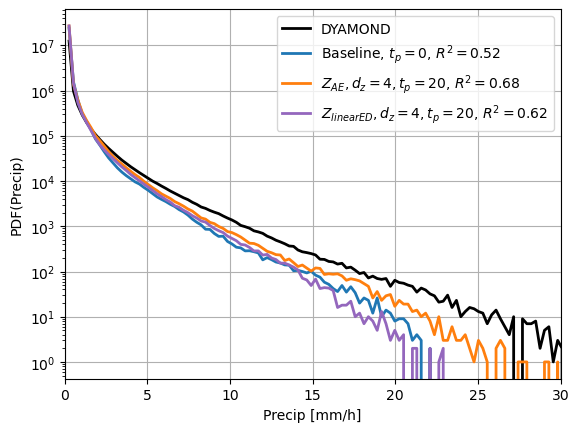

In [12]:
path_base = 'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20251209111425_global_ocean_land_rp=False_eps=1.0_Zval_NNbase_tp=0_wd=0.0.npy'
path_org_20_inf = 'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy'
precip, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
precip = precip[:, 21:]
precip_base_pred = precip_base_pred[:, 21:]
_, precip_org_pred, _ = get_precip(path_org_20_inf, rescale_precip=False)
precip_org_pred = precip_org_pred[:, 1:]
precip_org_ED_pred, precip_org_ED_True = np.load('20260417121500_Pr_combined_merged_val_test_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy')
precip_org_ED_pred = precip_org_ED_pred[:, -2*369: -369]
precip_org_ED_True = precip_org_ED_True[:, -2*369: -369]
#precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load('20260327125800_Pr_combined_residual_nonlinear_ODE_latent_dims=4_complexity=5p10_tp=20_global_oceanland.npy')
pt = None
density = False
_, bins = precip_hist(precip.flatten(), bins=200, alpha=1.0, label=r'DYAMOND', color='black', density=density)
print(len(bins))
R2_base = round(R2Score()(torch.tensor(precip_base_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
precip_hist(precip_base_pred.flatten(), bins=bins, alpha=1.0, color='tab:blue', label=rf'Baseline, $t_p = 0$, $R^2={{{R2_base}}}$', density=density)
R2_org = round(R2Score()(torch.tensor(precip_org_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
precip_hist(precip_org_pred.flatten(), bins=bins, alpha=1.0, color='tab:orange', label=rf'$Z_{{AE}}, d_z = 4, t_p = 20$, $R^2={{{R2_org}}}$', density=density)
R2_org_ed = round(R2Score()(torch.tensor(precip_org_ED_pred.flatten()), torch.tensor(precip_org_ED_True.flatten())).item(), 2)
precip_hist(precip_org_ED_pred.flatten(), bins=bins, alpha=1.0, color='tab:purple', label=rf'$Z_{{linear ED}}, d_z = 4, t_p = 20$, $R^2={{{R2_org_ed}}}$', density=density)
#R2_org_nonlined = round(R2Score()(torch.tensor(precip_org_nonlinED_pred.flatten()), torch.tensor(precip_org_nonlinED_True.flatten())).item(), 2)
#precip_hist(precip_org_nonlinED_pred.flatten(), bins=bins, alpha=1.0, color='tab:green', label=rf'$Z_{{nonlinear ED}}, d_z = 4, t_p = 20$, $R^2={{{R2_org_nonlined}}}$', density=density)
plt.yscale('log')
plt.legend()
plt.xlim(0, 30)
plt.grid()
plt.xlabel('Precip [mm/h]')
plt.ylabel('PDF(Precip)')
#plt.ylim(10, 3.e7)

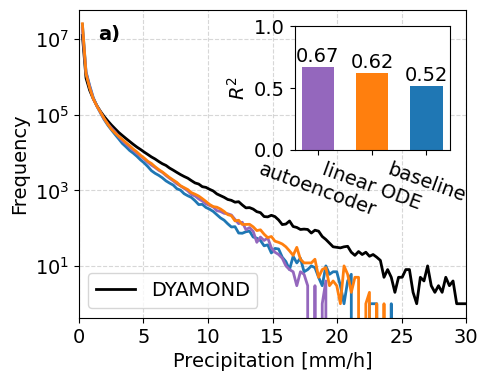

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import torch
from torchmetrics import R2Score

# =========================
# Load data
# =========================
#path_base = 'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20251209111425_global_ocean_land_rp=False_eps=1.0_Zval_NNbase_tp=0_wd=0.0.npy'
#path_base = 'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260417115838_global_ocean_land_rp=False_Zval_NNbase_tp=0_wd=None.npy'
path_base = 'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztest_NNbase_tp=0_wd=0.0.npy'
#path_org_20_inf = 'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy'
path_org_20_inf = 'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=0.0.npy'
#path_org_20_inf = 'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260417112208_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=None.npy'
precip, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
spinup = 20
precip = precip[:, 21 + spinup:]
precip_base_pred = precip_base_pred[:, 21 + spinup:]

_, precip_org_pred, _ = get_precip(path_org_20_inf, rescale_precip=False)
precip_org_pred = precip_org_pred[:, 1 + spinup:]
# precip_org = precip_org[:, 1:]

precip_org_ED_pred, precip_org_ED_True = np.load(
    #'20260319122900_Pr_combined_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
    #'20260417121500_Pr_combined_val_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
    'precip_ODE_predictions/20260511101043_Pr_combined_test_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
    #'precip_ODE_predictions/20260511101043_Pr_combined_train_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
)
precip_org_ED_pred = precip_org_ED_pred[:, spinup:]
precip_org_ED_True = precip_org_ED_True[:, spinup:]
# precip_org_ED_pred, precip_org_ED_True = np.load('20260417121500_Pr_combined_merged_val_test_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy')
# precip_org_ED_pred = precip_org_ED_pred[:, -1*369:]
# precip_org_ED_True = precip_org_ED_True[:, -1*369:]
#precip_org_ED_pred = precip_org_ED_pred.reshape(369, -1).T
#precip_org_ED_True = precip_org_ED_True.reshape(369, -1).T

# =========================
# Compute R²
# =========================
R2_base = round(R2Score()(torch.tensor(precip_base_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
R2_org = round(R2Score()(torch.tensor(precip_org_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
R2_org_ed = round(R2Score()(torch.tensor(precip_org_ED_pred.flatten()), torch.tensor(precip_org_ED_True.flatten())).item(), 2)

# =========================
# Main PDF plot
# =========================
fig, ax = plt.subplots(figsize=(5, 4))
FS = 14
density = False

# Ground truth
_, bins = precip_hist(precip.flatten(), bins=120, alpha=1.0, color='black', density=density, label='DYAMOND')

# Models
precip_hist(precip_base_pred.flatten(),bins=bins,alpha=1.0,color='tab:blue',density=density,label=None)
precip_hist(precip_org_pred.flatten(),bins=bins,alpha=1.0,color='tab:purple',density=density,label=None)
precip_hist(precip_org_ED_pred.flatten(),bins=bins,alpha=1.0,color='tab:orange',density=density,label=None)

# Axes styling
ax.set_yscale('log')
ax.set_xlim(0, 30)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel('Precipitation [mm/h]', fontsize=FS)
ax.set_ylabel('Frequency', fontsize=FS)
ax.tick_params(axis='both', labelsize=FS)
ax.legend(loc='lower left', fontsize=FS)
ax.text(.05, .95, 'a)', ha='left', va='top', fontweight='bold', fontsize=FS, transform=ax.transAxes)

# =========================
# Inset: R² bar plot
# =========================
axins = inset_axes(ax, width="40%", height="40%", loc='upper right', borderpad=1.2)
r2_values = [R2_org, R2_org_ed, R2_base]
colors = ['tab:purple', 'tab:orange', 'tab:blue']
labels = ['autoencoder','linear ODE','baseline']
bars = axins.bar(range(len(r2_values)), r2_values, color=colors, width=0.6)

# Annotate R² values
for i, v in enumerate(r2_values):
    axins.text(i, v + 0.01, f"{v:.2f}",
               ha='center', va='bottom', fontsize=FS)

axins.set_xticks(range(len(labels)))
axins.set_xticklabels(labels, fontsize=FS, rotation=-20)
axins.set_ylabel(r'$R^2$', fontsize=FS)
axins.set_ylim(0, 1)
axins.tick_params(axis='y', labelsize=FS)

# Clean inset appearance
# axins.spines['top'].set_visible(False)
# axins.spines['right'].set_visible(False)

#plt.show()
#plt.savefig('plots_paper/DYAMOND_R2.png', dpi=300, bbox_inches='tight')

train
val
test


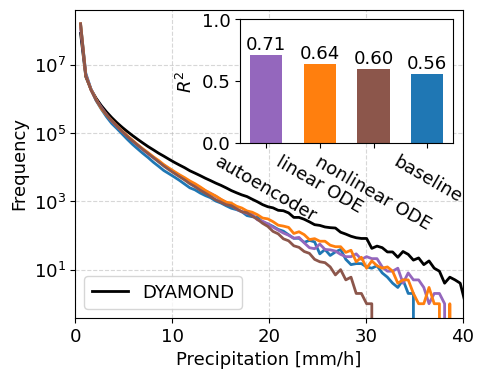

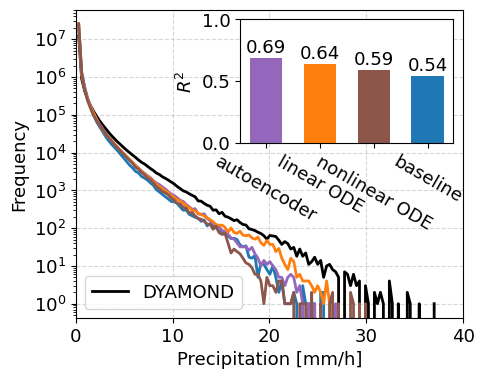

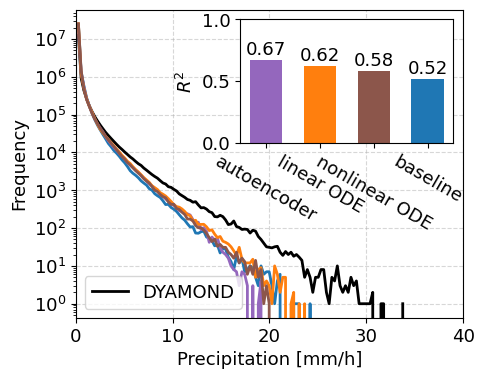

In [13]:
def precip_plot(path_base, path_org, path_org_ED, path_org_nonlinED, spinup=20, past_timesteps=20, save=False,
                file_name='DYAMOND_R2.pdf'):
    precip, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
    precip = precip[:, past_timesteps + 1 + spinup:]
    precip_base_pred = precip_base_pred[:, past_timesteps + 1 + spinup:]

    _, precip_org_pred, _ = get_precip(path_org, rescale_precip=False)
    precip_org_pred = precip_org_pred[:, 1 + spinup:]

    precip_org_ED_pred, precip_org_ED_True = np.load(path_org_ED)
    precip_org_ED_pred = precip_org_ED_pred[:, spinup:]
    precip_org_ED_True = precip_org_ED_True[:, spinup:]
    if path_org_nonlinED:
        precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load(path_org_nonlinED)
        precip_org_nonlinED_pred = precip_org_nonlinED_pred[:, spinup:]
        precip_org_nonlinED_True = precip_org_nonlinED_True[:, spinup:]
    # =========================
    # Compute R²
    # =========================
    R2_base = round(R2Score()(torch.tensor(precip_base_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
    R2_org = round(R2Score()(torch.tensor(precip_org_pred.flatten()), torch.tensor(precip.flatten())).item(), 2)
    R2_org_ed = round(R2Score()(torch.tensor(precip_org_ED_pred.flatten()), torch.tensor(precip_org_ED_True.flatten())).item(), 2)

    # =========================
    # Main PDF plot
    # =========================
    fig, ax = plt.subplots(figsize=(5, 4))
    FS = 13
    density = False

    # Ground truth
    _, bins = precip_hist(precip.flatten(), bins=120, alpha=1.0, color='black', density=density, label='DYAMOND')

    # Models
    precip_hist(precip_base_pred.flatten(),bins=bins,alpha=1.0,color='tab:blue',density=density,label=None)
    precip_hist(precip_org_pred.flatten(),bins=bins,alpha=1.0,color='tab:purple',density=density,label=None)
    precip_hist(precip_org_ED_pred.flatten(),bins=bins,alpha=1.0,color='tab:orange',density=density,label=None)
    if path_org_nonlinED:
        R2_org_nonlined = round(R2Score()(torch.tensor(precip_org_nonlinED_pred.flatten()), torch.tensor(precip_org_nonlinED_True.flatten())).item(), 2)
        precip_hist(precip_org_nonlinED_pred.flatten(), bins=bins, alpha=1.0, color='tab:brown', density=density, label=None)

    # Axes styling
    ax.set_yscale('log')
    ax.set_xlim(0, 40)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlabel('Precipitation [mm/h]', fontsize=FS)
    ax.set_ylabel('Frequency', fontsize=FS)
    ax.tick_params(axis='both', labelsize=FS)
    ax.legend(loc='lower left', fontsize=FS)
    # ax.text(.05, .95, 'a)', ha='left', va='top', fontweight='bold', fontsize=FS, transform=ax.transAxes)

    # =========================
    # Inset: R² bar plot
    # =========================
    axins = inset_axes(ax, width="55%", height="40%", loc='upper right', borderpad=0.7)
    r2_values = [R2_org, R2_org_ed, R2_base]
    colors = ['tab:purple', 'tab:orange', 'tab:blue']
    labels = ['autoencoder','linear ODE','baseline']
    if path_org_nonlinED:
        r2_values.insert(2, R2_org_nonlined)
        colors.insert(2, 'tab:brown')
        labels.insert(2, 'nonlinear ODE')
    bars = axins.bar(range(len(r2_values)), r2_values, color=colors, width=0.6)

    # Annotate R² values
    for i, v in enumerate(r2_values):
        axins.text(i, v + 0.01, f"{v:.2f}",
                ha='center', va='bottom', fontsize=FS)

    axins.set_xticks(range(len(labels)))
    axins.set_xticklabels(labels, fontsize=FS, rotation=-30)
    axins.set_ylabel(r'$R^2$', fontsize=FS)
    axins.set_ylim(0, 1)
    axins.tick_params(axis='y', labelsize=FS)

    # Clean inset appearance
    # axins.spines['top'].set_visible(False)
    # axins.spines['right'].set_visible(False)

    if save:
        plt.savefig(file_name, dpi=300, bbox_inches='tight')

for dataset in ['train', 'val', 'test']:
    print(dataset)
    path_base = f'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Z{dataset}_NNbase_tp=0_wd=0.0.npy'
    path_org_20_inf = f'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Z{dataset}_ConvNN+AE+D_tp=20_wd=0.0.npy'
    path_org_ED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
    path_org_nonlinED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy'

    precip_plot(path_base, path_org_20_inf, path_org_ED, path_org_nonlinED, save=True, file_name=f'plots_paper/DYAMOND_R2_{dataset}.png')

In [43]:
precip_org_ED_pred, precip_org_ED_True = np.load(
    #'20260319122900_Pr_combined_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
    '20260417121500_Pr_combined_val_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
)

precip_org_ED_True.shape

(81920, 369)

In [5]:
import cartopy.crs as ccrs
grid_path='/work/bd1179/b309297/DYAMOND_experiment/DYAMOND/icon_grid_0019_R02B05_G.nc'
grid = load_grid(grid_path)
lon, lat = grid.clon.values, grid.clat.values

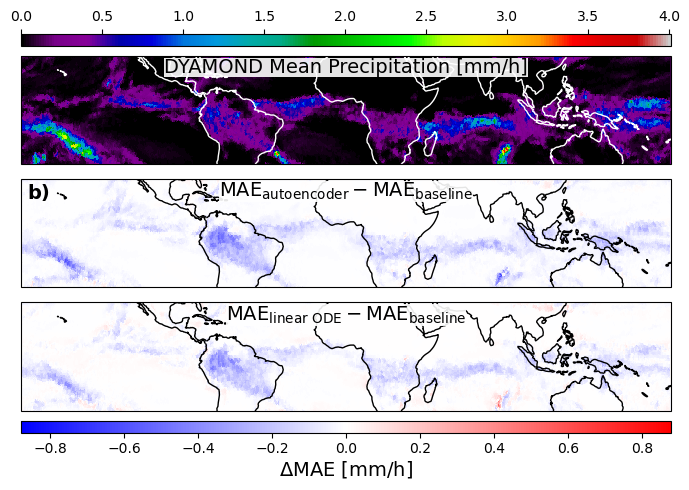

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.gridspec import GridSpec

# =========================
# Settings
# =========================
tropics_min, tropics_max = -30, 30
proj = ccrs.PlateCarree()

# =========================
# Figure + GridSpec (ultra compact)
# =========================
fig = plt.figure(figsize=(7, 5))
FS = 14
gs = GridSpec(
    5, 1,
    figure=fig,
    height_ratios=[0.15, 1.5, 1.5, 1.5, 0.15],
)

# Axes
cax_top = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], projection=proj)
ax2 = fig.add_subplot(gs[2], projection=proj)
ax3 = fig.add_subplot(gs[3], projection=proj)
cax_bottom = fig.add_subplot(gs[4])
ax2.text(0.01, 0.95, 'b)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax2.transAxes)
# =========================
# Panel 1
# =========================
mean_precip = np.mean(precip, axis=1)

sc1 = ax1.tripcolor(
    lon, lat, mean_precip,
    transform=proj,
    cmap="nipy_spectral",
    vmin=0.0,
    vmax=mean_precip.max()
)

# =========================
# MAE fields
# =========================
MAE_org = np.mean(np.abs(precip_org_pred - precip), axis=1)
MAE_base = np.mean(np.abs(precip_base_pred - precip), axis=1)
MAE_ED = np.mean(np.abs(precip_org_ED_pred - precip_org_ED_True), axis=1)

vscale = np.max(np.abs(MAE_org - MAE_base))
cmap_MAE = "bwr"

sc2 = ax2.tripcolor(
    lon, lat, MAE_org - MAE_base,
    transform=proj,
    cmap=cmap_MAE,
    vmin=-vscale,
    vmax=vscale
)

sc3 = ax3.tripcolor(
    lon, lat, MAE_ED - MAE_base,
    transform=proj,
    cmap=cmap_MAE,
    vmin=-vscale,
    vmax=vscale
)

# =========================
# Shared formatting (tight)
# =========================
labels = [
    "DYAMOND Mean Precipitation [mm/h]",
    r"$\text{MAE}_{\text{autoencoder}} - \text{MAE}_{\text{baseline}}$",
    r"$\text{MAE}_{\text{linear ODE}} - \text{MAE}_{\text{baseline}}$"
]

for ax, label, c in zip([ax1, ax2, ax3], labels, ['white', 'black', 'black']):
    ax.set_extent([lon.min(), lon.max(), tropics_min, tropics_max], crs=proj)
    ax.coastlines(resolution="110m", color=c)

    ax.text(
        0.5, 0.98, label,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=FS,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=0)
    )

# =========================
# Colorbars (embedded in grid)
# =========================
cb1 = fig.colorbar(sc1, cax=cax_top, orientation="horizontal")
cb1.ax.xaxis.set_ticks_position("top")
#cb1.set_label("DYAMOND Mean Precipitation [mm/h]", fontsize=10)

cb2 = fig.colorbar(sc3, cax=cax_bottom, orientation="horizontal")
cb2.set_label(r"$\Delta$MAE [mm/h]", fontsize=FS, labelpad=2)

# =========================
# Final tightening
# =========================
plt.subplots_adjust(left=0.06, right=0.98, top=0.98, bottom=0.04)
plt.tight_layout()
#plt.show()
#plt.savefig('plots_paper/DYAMOND_MAE_global.png', dpi=300, bbox_inches='tight')

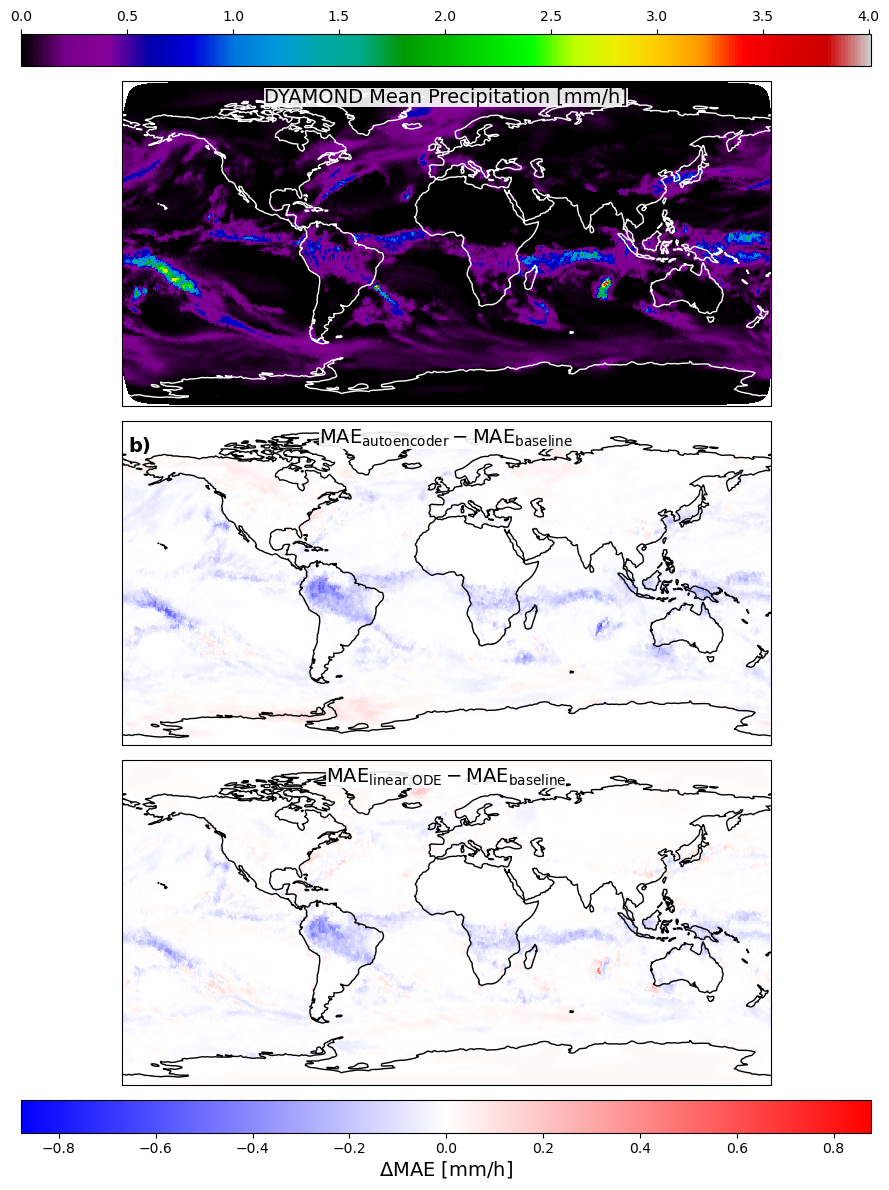

In [14]:
# =========================
# Settings
# =========================
tropics_min, tropics_max = -90, 90
proj = ccrs.PlateCarree()

# =========================
# Figure + GridSpec (ultra compact)
# =========================
fig = plt.figure(figsize=(9, 12))
FS = 14
gs = GridSpec(
    5, 1,
    figure=fig,
    height_ratios=[0.15, 1.5, 1.5, 1.5, 0.15],
)

# Axes
cax_top = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], projection=proj)
ax2 = fig.add_subplot(gs[2], projection=proj)
ax3 = fig.add_subplot(gs[3], projection=proj)
cax_bottom = fig.add_subplot(gs[4])
ax2.text(0.01, 0.95, 'b)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax2.transAxes)
# =========================
# Panel 1
# =========================
mean_precip = np.mean(precip, axis=1)

sc1 = ax1.tripcolor(
    lon, lat, mean_precip,
    transform=proj,
    cmap="nipy_spectral",
    vmin=0.0,
    vmax=mean_precip.max()
)

# =========================
# MAE fields
# =========================
MAE_org = np.mean(np.abs(precip_org_pred - precip), axis=1)
MAE_base = np.mean(np.abs(precip_base_pred - precip), axis=1)
MAE_ED = np.mean(np.abs(precip_org_ED_pred - precip_org_ED_True), axis=1)

vscale = np.max(np.abs(MAE_org - MAE_base))
cmap_MAE = "bwr"

sc2 = ax2.tripcolor(
    lon, lat, MAE_org - MAE_base,
    transform=proj,
    cmap=cmap_MAE,
    vmin=-vscale,
    vmax=vscale
)

sc3 = ax3.tripcolor(
    lon, lat, MAE_ED - MAE_base,
    transform=proj,
    cmap=cmap_MAE,
    vmin=-vscale,
    vmax=vscale
)

# =========================
# Shared formatting (tight)
# =========================
labels = [
    "DYAMOND Mean Precipitation [mm/h]",
    r"$\text{MAE}_{\text{autoencoder}} - \text{MAE}_{\text{baseline}}$",
    r"$\text{MAE}_{\text{linear ODE}} - \text{MAE}_{\text{baseline}}$"
]

for ax, label, c in zip([ax1, ax2, ax3], labels, ['white', 'black', 'black']):
    ax.set_extent([lon.min(), lon.max(), tropics_min, tropics_max], crs=proj)
    ax.coastlines(resolution="110m", color=c)

    ax.text(
        0.5, 0.98, label,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=FS,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=0)
    )

# =========================
# Colorbars (embedded in grid)
# =========================
cb1 = fig.colorbar(sc1, cax=cax_top, orientation="horizontal")
cb1.ax.xaxis.set_ticks_position("top")
#cb1.set_label("DYAMOND Mean Precipitation [mm/h]", fontsize=10)

cb2 = fig.colorbar(sc3, cax=cax_bottom, orientation="horizontal")
cb2.set_label(r"$\Delta$MAE [mm/h]", fontsize=FS, labelpad=2)

# =========================
# Final tightening
# =========================
plt.subplots_adjust(left=0.06, right=0.98, top=0.98, bottom=0.04)
plt.tight_layout()
#plt.show()
plt.savefig('plots_paper/DYAMOND_MAE_global.png', dpi=300, bbox_inches='tight')

### Temporal MAE

In [5]:
def plot_temporal_MAE(precip_pred, precip_true, fig=None, ax=None, plot_kwargs={}, t0=0):
    if not fig:
        fig, ax = plt.subplots()
    # precip_pred = precip_pred.reshape(-1, 369)
    # precip_true = precip_true.reshape(-1, 369)
    mae = np.mean(np.abs(precip_pred - precip_true), axis=0)
    t = np.arange(precip_pred.shape[1]) * 15 / (60*24) + t0
    ax.plot(t, mae, **plot_kwargs)
    ax.set(xlabel='Time [days]', ylabel='Precipitation MAE [mm/h]')

# fig, ax = plt.subplots()
# plot_temporal_MAE(precip_base_pred, precip, plot_kwargs={'color': 'tab:blue', 'label': 'baseline'}, fig=fig, ax=ax)
# plot_temporal_MAE(precip_org_pred_train, precip_org_train, plot_kwargs={'color': 'tab:orange', 'label': 'Z_AE'}, fig=fig, ax=ax, t0=0.20833)  # t0=22.26+0.20833
# plot_temporal_MAE(precip_org_pred_val, precip_org_val, plot_kwargs={'color': 'tab:orange'}, fig=fig, ax=ax, t0=22.26 + 0.20833)  # t0=22.26+0.20833
# plot_temporal_MAE(precip_org_ED_pred, precip_org_ED_True, plot_kwargs={'color': 'tab:purple', 'label': 'linear ED'}, fig=fig, ax=ax, t0=0.20833)
# plt.ylim(0.08, 0.15)
# #plt.xlim(20, 27)
# plt.vlines(x=22.26 + 0.20833, ymin=0.05, ymax=0.2, color='grey', linestyle='--', label='start of validation set')
# ax.legend(loc='upper left')

In [6]:
# Load all data for merged plot
# Baseline and autoencoder are stored seperately for train, val, test, so we need to merge them. The ODE predictions are already merged.
precip_org_merged, precip_base_merged, precip = [], [], []
tp = 20 
Ncoords = 81920
spinup = np.empty(shape=(Ncoords, tp))
spinup[:] = np.nan
for dataset in ['train', 'val', 'test']:
    # Load individual datasets
    path_base = f'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Z{dataset}_NNbase_tp=0_wd=0.0.npy'
    path_org = f'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Z{dataset}_ConvNN+AE+D_tp=20_wd=0.0.npy'
    _, precip_org_pred, _ = get_precip(path_org, rescale_precip=False)
    precip_true, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
    precip_org_merged.append(spinup)  # add spinup time of autoencoder as NaN values to align with ODE predictions
    precip_org_merged.append(precip_org_pred)
    precip_base_merged.append(precip_base_pred)
    precip.append(precip_true)

dataset = 'merged'
path_org_ED  = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
path_org_nonlinED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
precip_org_ED_pred, precip_org_ED_True = np.load(path_org_ED)
precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load(path_org_nonlinED)
precip_org_merged = np.concatenate(precip_org_merged, axis=1)
precip_base_merged = np.concatenate(precip_base_merged, axis=1)
precip = np.concatenate(precip, axis=1)
precip_org_merged = precip_org_merged[:, 1:]
precip_base_merged = precip_base_merged[:, 1:]
precip = precip[:, 1:]

In [7]:
# Remove Nans from time series for R² computation (only for merged plot, since individual train/val/test plots are already aligned)
mask = ~np.isnan(precip_org_merged.flatten()) 
precip_org_merged_flat = precip_org_merged.flatten()[mask]
precip_flat = precip.flatten()[mask]
R2_org_merged = R2Score()(torch.tensor(precip_org_merged_flat), torch.tensor(precip_flat)).item()
R2_org_merged 

0.6996131402071

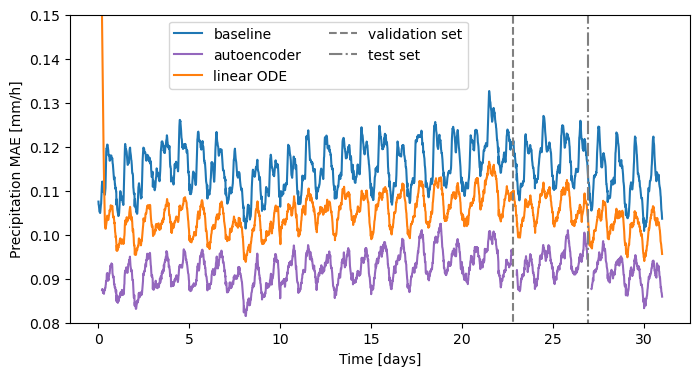

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_temporal_MAE(precip_base_merged, precip, plot_kwargs={'color': 'tab:blue', 'label': 'baseline'}, fig=fig, ax=ax)
plot_temporal_MAE(precip_org_merged, precip, plot_kwargs={'color': 'tab:purple', 'label': 'autoencoder'}, fig=fig, ax=ax)
plot_temporal_MAE(precip_org_ED_pred, precip_org_ED_True, plot_kwargs={'color': 'tab:orange', 'label': 'linear ODE'}, fig=fig, ax=ax)
# plot_temporal_MAE(precip_org_nonlinED_pred, precip_org_nonlinED_True, plot_kwargs={'color': 'tab:brown', 'label': 'nonlinear ODE'}, fig=fig, ax=ax)
ax.set_ylim(0.08, 0.15)
ax.vlines(x=(22.79), ymin=0.05, ymax=0.2, color='grey', linestyle='--', label='validation set')
ax.vlines(x=(26.89), ymin=0.05, ymax=0.2, color='grey', linestyle='-.', label='test set')
ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.4, 1.0))
plt.savefig('plots_paper/DYAMOND_temporal_MAE_merged_without_nonlin.png', dpi=300, bbox_inches='tight')

### Diurnal cycle

In [42]:
import cartopy.crs as ccrs
grid_path='/work/bd1179/b309297/DYAMOND_experiment/DYAMOND/icon_grid_0019_R02B05_G.nc'
grid = load_grid(grid_path)
lon, lat = grid.clon.values, grid.clat.values
ds = xr.open_dataset('merged_15min_full_ICON-NWP-2km_DW-ATM_r1i1p1f1_2d_gn_20200120000000-20200301000000_R02B05.nc')
ds_time = ds.time.values

land = grid.cell_sea_land_mask.values == 2
ocean = grid.cell_sea_land_mask.values == -2

In [52]:
print(np.sum(land), np.sum(ocean))

22659 54702


In [3]:
import numpy as np


def compute_diurnal_cycle_localtime(
    data,
    lon,
    steps_per_day=96,
):
    """
    Compute tropical diurnal cycle in LOCAL SOLAR TIME.

    Parameters
    ----------
    data : np.ndarray
        Shape (n_points, n_timesteps)

    lon : np.ndarray
        Longitudes in degrees, shape (n_points,)
        Expected range either [-180, 180] or [0, 360]

    steps_per_day : int
        Number of timesteps per day.
        Example:
            96  -> 15 min data
            24  -> hourly data

    Returns
    -------
    diurnal_cycle : np.ndarray
        Mean diurnal cycle in local time,
        shape (steps_per_day,)
    """

    n_points, n_timesteps = data.shape
    n_days = n_timesteps // steps_per_day

    # truncate to complete days
    data = data[:, :n_days * steps_per_day]

    # reshape to (n_points, n_days, steps_per_day)
    data = data.reshape(n_points, n_days, steps_per_day)

    # convert longitude to local-time shift
    #
    # 360 deg = 24 h
    # shift in timesteps:
    #
    #   offset_steps = lon / 360 * steps_per_day
    #
    offset_steps = np.round(lon / 360.0 * steps_per_day).astype(int)

    # shift each grid point independently
    shifted = np.empty_like(data)

    for i in range(n_points):
        shifted[i] = np.roll(data[i], -offset_steps[i], axis=-1)

    # average over space + days
    diurnal_cycle = shifted.mean(axis=(0, 1))

    return diurnal_cycle


def evaluate_diurnal(model_cycle, truth_cycle):

    rmse = np.sqrt(np.mean((model_cycle - truth_cycle) ** 2))

    bias = np.mean(model_cycle - truth_cycle)

    corr = np.corrcoef(model_cycle, truth_cycle)[0, 1]

    return {
        "RMSE": rmse,
        "Bias": bias,
        "Correlation": corr,
    }


def run_evaluation(model_data_list, truth_data_list, lon_list):

    results = []

    for i, (model_data, truth_data, lon) in enumerate(
        zip(model_data_list, truth_data_list, lon_list)
    ):

        model_cycle = compute_diurnal_cycle_localtime(
            model_data,
            lon,
        )

        truth_cycle = compute_diurnal_cycle_localtime(
            truth_data,
            lon,
        )

        metrics = evaluate_diurnal(model_cycle, truth_cycle)

        results.append({
            "model": i,
            "metrics": metrics,
            "model_cycle": model_cycle,
            "truth_cycle": truth_cycle,
        })

    return results

In [67]:
tp = 20 
Ncoords = 81920
spinup = 20
dataset = 'test'

# Load individual datasets
path_base = f'Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Z{dataset}_NNbase_tp=0_wd=0.0.npy'
path_org = f'Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Z{dataset}_ConvNN+AE+D_tp=20_wd=0.0.npy'
path_org_ED  = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy'
path_org_nonlinED = f'precip_ODE_predictions/20260511101043_Pr_combined_{dataset}_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy'

precip_org_ED_pred, precip_org_ED_True = np.load(path_org_ED)[:, :, spinup:]
precip_org_nonlinED_pred, precip_org_nonlinED_True = np.load(path_org_nonlinED)[:, :, spinup:]
_, precip_org_pred, _ = get_precip(path_org, rescale_precip=False)
precip_org_pred = precip_org_pred[:, 1 + spinup:]
precip_true, precip_base_pred, _ = get_precip(path_base, rescale_precip=False)
precip_true = precip_true[:, tp + 1 + spinup:]
precip_base_pred = precip_base_pred[:, tp + 1 + spinup:]

autoencoder Phase=  84 , Amplitude=  0.1721168
autoencoder Phase=  90 , Amplitude=  0.18406947
linear ODE Phase=  84 , Amplitude=  0.19794552
linear ODE Phase=  91 , Amplitude=  0.18406947


baseline Phase=  84 , Amplitude=  0.18625866
baseline Phase=  90 , Amplitude=  0.18406947
nonlinear ODE Phase=  84 , Amplitude=  0.18804866
nonlinear ODE Phase=  91 , Amplitude=  0.18406947


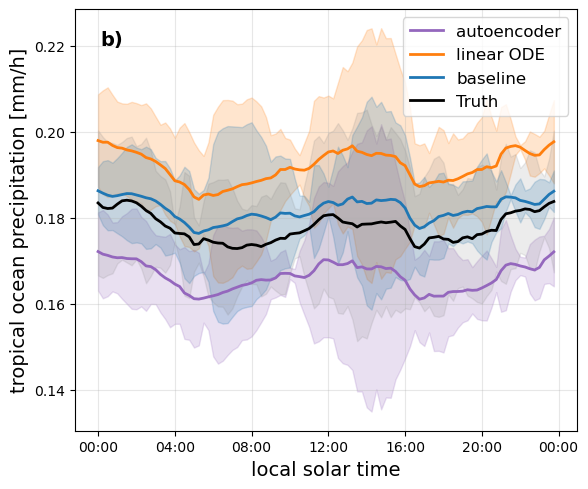

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# --- 1. Helper Functions ---
def compute_diurnal_cycle_with_ci(data, lon, steps_per_day=96, ci=0.95, model_name=None):
    n_points, n_timesteps = data.shape
    n_days = n_timesteps // steps_per_day
    data = data[:, :n_days * steps_per_day]
    data = data.reshape(n_points, n_days, steps_per_day)
    
    offset_steps = np.round(lon / 360.0 * steps_per_day).astype(int)
    shifted = np.empty_like(data)
    for i in range(n_points):
        shifted[i] = np.roll(data[i], -offset_steps[i], axis=-1)
        
    daily_cycles = shifted.mean(axis=0)
    mean_cycle = daily_cycles.mean(axis=0)
    std_cycle = daily_cycles.std(axis=0, ddof=1)
    print(f'{model_name} Phase= ', np.argmax(mean_cycle), ', Amplitude= ', np.max(mean_cycle))
    
    t_val = stats.t.ppf((1 + ci) / 2, df=n_days - 1)
    se = std_cycle / np.sqrt(n_days)
    return mean_cycle, mean_cycle - t_val * se, mean_cycle + t_val * se

def evaluate_diurnal(model_cycle, truth_cycle):
    rmse = np.sqrt(np.mean((model_cycle - truth_cycle) ** 2))
    bias = np.mean(model_cycle - truth_cycle)
    corr = np.corrcoef(model_cycle, truth_cycle)[0, 1]
    return {"RMSE": rmse, "Bias": bias, "Correlation": corr}

def run_evaluation_with_ci(model_data_list, truth_data_list, lon_list, model_names=None):
    if model_names is None:
        model_names = [f"model_{i}" for i in range(len(model_data_list))]
        
    results = []
    for i, (model_data, truth_data, lon, model_name) in enumerate(zip(model_data_list, truth_data_list, lon_list, model_names)):
        model_cycle, model_lower, model_upper = compute_diurnal_cycle_with_ci(model_data, lon, model_name=model_name)
        truth_cycle, truth_lower, truth_upper = compute_diurnal_cycle_with_ci(truth_data, lon, model_name=model_name)
        
        metrics = evaluate_diurnal(model_cycle, truth_cycle)
        
        results.append({
            "model": model_names[i],
            "metrics": metrics,
            "model_cycle": model_cycle,
            "truth_cycle": truth_cycle,
            "lower": model_lower,
            "upper": model_upper,
            "truth_lower": truth_lower,
            "truth_upper": truth_upper,
        })
    return results

# --- 2. CONFIGURATION: Pick which models to show ---
models_to_plot = ['linear ODE', 'autoencoder', 'baseline'] 

# --- 3. DATA SETUP (Your exact variables) ---
tropics_max, tropics_min = 23.5, -23.5
# add_nonlin = True
line_width = 2
tropical_mask = (lat >= tropics_min) & (lat <= tropics_max)
mask = tropical_mask & ocean

model_data_list = [precip_org_pred[mask], precip_org_ED_pred[mask], precip_base_pred[mask], precip_org_nonlinED_pred[mask]]
truth_data_list = [precip_true[mask], precip_org_ED_True[mask], precip_true[mask], precip_org_nonlinED_True[mask]]
lon_list = [lon[mask], lon[mask], lon[mask], lon[mask]]
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'tab:brown']
labels = ['autoencoder', 'linear ODE', 'baseline', 'nonlinear ODE']

# if add_nonlin:
#     model_data_list.append(precip_org_nonlinED_pred[mask])
#     truth_data_list.append(precip_org_nonlinED_True[mask])
#     lon_list.append(lon[mask])
#     colors.append('tab:brown')
#     labels.append('nonlinear ODE')

roll = 12  # Because test set starts 03:00, but diurnal cycle should start at 00:00 local time
t = ds_time[-373 - roll: -373 - roll + 96]

# Run evaluation
results = run_evaluation_with_ci(model_data_list, truth_data_list, lon_list, model_names=labels)

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(6, 5))
FS = 14

# Plot selected models
for res, label, c in zip(results, labels, colors):
    if label not in models_to_plot:
        continue
        
    cycle_rolled = np.roll(res["model_cycle"], roll)
    lower_rolled = np.roll(res["lower"], roll)
    upper_rolled = np.roll(res["upper"], roll)
    
    ax.plot(t, cycle_rolled, color=c, linewidth=line_width, label=label)
    ax.fill_between(t, lower_rolled, upper_rolled, color=c, alpha=0.2)

# Plot Truth (always shown)
# Extract truth from the first result (truth_data_list[0] is the main truth)
truth_cycle = results[0]["truth_cycle"]
truth_lower = results[0]["truth_lower"]
truth_upper = results[0]["truth_upper"]

truth_cycle_rolled = np.roll(truth_cycle, roll)
truth_lower_rolled = np.roll(truth_lower, roll)
truth_upper_rolled = np.roll(truth_upper, roll)

ax.plot(t, truth_cycle_rolled, color='black', linewidth=line_width, label='Truth')
ax.fill_between(t, truth_lower_rolled, truth_upper_rolled, color='gray', alpha=0.15)
# Formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.text(0.05, 0.95, 'b)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax.transAxes)
ax.set_xlabel("local solar time", fontsize=FS)
ax.set_ylabel("tropical ocean precipitation [mm/h]", fontsize=FS)
ax.legend(loc='upper right', fontsize=FS-2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'plots_paper/DYAMOND_diurnal_cycle_ocean_models={models_to_plot}.png', dpi=300, bbox_inches='tight')

In [103]:
print(t[(roll + 91) % 96])
print(t[(roll + 84) % 96])

2020-02-26T01:45:00.000000000
2020-02-26T00:00:00.000000000


autoencoder Phase=  59 , Amplitude=  0.20696722
autoencoder Phase=  62 , Amplitude=  0.21215491
linear ODE Phase=  61 , Amplitude=  0.21785377
linear ODE Phase=  63 , Amplitude=  0.21195376
baseline Phase=  36 , Amplitude=  0.2132696
baseline Phase=  62 , Amplitude=  0.21215491
nonlinear ODE Phase=  65 , Amplitude=  0.1949215
nonlinear ODE Phase=  63 , Amplitude=  0.21195376
2020-02-26T18:30:00.000000000


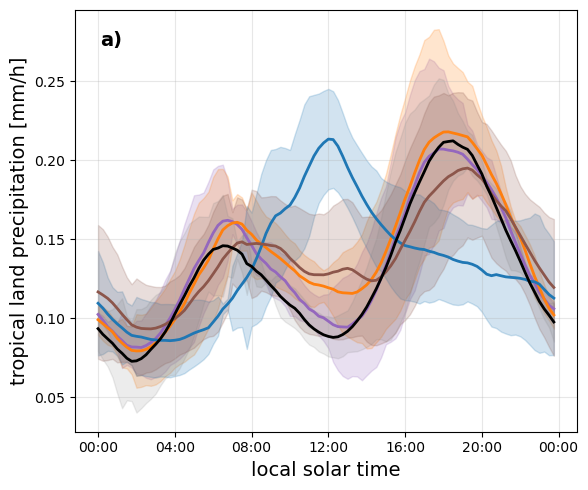

In [123]:
# --- 2. CONFIGURATION: Pick which models to show ---
models_to_plot = ['linear ODE', 'autoencoder', 'baseline', 'nonlinear ODE']  # <-- Edit this list!

# --- 3. DATA SETUP (Your exact variables) ---
tropics_max, tropics_min = 23.5, -23.5
# add_nonlin = True
line_width = 2
tropical_mask = (lat >= tropics_min) & (lat <= tropics_max)
mask = tropical_mask & land

model_data_list = [precip_org_pred[mask], precip_org_ED_pred[mask], precip_base_pred[mask], precip_org_nonlinED_pred[mask]]
truth_data_list = [precip_true[mask], precip_org_ED_True[mask], precip_true[mask], precip_org_nonlinED_True[mask]]
lon_list = [lon[mask], lon[mask], lon[mask], lon[mask]]
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'tab:brown']
labels = ['autoencoder', 'linear ODE', 'baseline', 'nonlinear ODE']

# if add_nonlin:
#     model_data_list.append(precip_org_nonlinED_pred[mask])
#     truth_data_list.append(precip_org_nonlinED_True[mask])
#     lon_list.append(lon[mask])
#     colors.append('tab:brown')
#     labels.append('nonlinear ODE')

roll = 12  # Because test set starts 03:00, but diurnal cycle should start at 00:00 local time
t = ds_time[-373 - roll: -373 - roll + 96]

# Run evaluation
results = run_evaluation_with_ci(model_data_list, truth_data_list, lon_list, model_names=labels)

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(6, 5))
FS = 14

# Plot selected models
for res, label, c in zip(results, labels, colors):
    if label not in models_to_plot:
        continue
        
    cycle_rolled = np.roll(res["model_cycle"], roll)
    lower_rolled = np.roll(res["lower"], roll)
    upper_rolled = np.roll(res["upper"], roll)
    
    ax.plot(t, cycle_rolled, color=c, linewidth=line_width, label=label)
    ax.fill_between(t, lower_rolled, upper_rolled, color=c, alpha=0.2)

# Plot Truth (always shown)
# Extract truth from the first result (truth_data_list[0] is the main truth)
truth_cycle = results[0]["truth_cycle"]
truth_lower = results[0]["truth_lower"]
truth_upper = results[0]["truth_upper"]

truth_cycle_rolled = np.roll(truth_cycle, roll)
truth_lower_rolled = np.roll(truth_lower, roll)
truth_upper_rolled = np.roll(truth_upper, roll)

ax.plot(t, truth_cycle_rolled, color='black', linewidth=line_width, label='Truth')
ax.fill_between(t, truth_lower_rolled, truth_upper_rolled, color='gray', alpha=0.15)
print(t[roll + 62])
# Formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
ax.text(0.05, 0.95, 'a)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax.transAxes)
ax.set_xlabel("local solar time", fontsize=FS)
ax.set_ylabel("tropical land precipitation [mm/h]", fontsize=FS)
# ax.legend(loc='upper right', fontsize=FS-2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'plots_paper/DYAMOND_diurnal_cycle_land_models={models_to_plot}.png', dpi=300, bbox_inches='tight')

In [106]:
print('AE ', t[(roll + 59) % 96])
print('ODE ',t[(roll + 61) % 96])
print('base ',t[(roll + 36) % 96])
print('ture ',t[(roll + 65) % 96])
print('nonlin ODE ',t[(roll + 62) % 96])

AE  2020-02-26T17:45:00.000000000
ODE  2020-02-26T18:15:00.000000000
base  2020-02-26T12:00:00.000000000
ture  2020-02-26T19:15:00.000000000
nonlin ODE  2020-02-26T18:30:00.000000000


Text(0, 0.5, 'tropical precipitation [mm/h]')

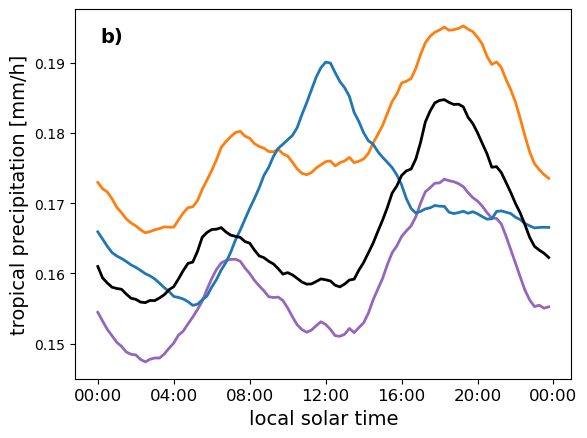

In [9]:
tropics_max, tropics_min = 23.5, -23.5
add_nonlin = False
line_width = 2
#tropics_max, tropics_min = 90, -90
tropical_mask = (lat >= tropics_min) & (lat <= tropics_max)
mask = tropical_mask
model_data_list = [precip_org_pred[mask], precip_org_ED_pred[mask], precip_base_pred[mask]]  # list of model predictions
truth_data_list = [precip_true[mask], precip_org_ED_True[mask], precip_true[mask]]  # can reuse same truth if needed
lon_list = [lon[mask], lon[mask], lon[mask]]  # longitudes for local time conversion
colors = ['tab:purple', 'tab:orange', 'tab:blue']
labels = ['autoencoder', 'linear ODE', 'baseline']
if add_nonlin:
    model_data_list.append(precip_org_nonlinED_pred[mask])
    truth_data_list.append(precip_org_nonlinED_True[mask])
    lon_list.append(lon[mask])
    colors.append('tab:brown')
    labels.append('nonlinear ODE')
roll = 12  # roll data to desired starting time (e.g., 00:00 local solar time)
t = ds_time[-373 - roll: -373 - roll + 96]
results = run_evaluation(model_data_list, truth_data_list, lon_list)

for res, label, c in zip(results, labels, colors):
    plt.plot(t, np.roll(res["model_cycle"], roll), label=label, color=c, linewidth=line_width)
import matplotlib.dates as mdates
# show only time on x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# Specify xticks interval
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))

FS = 14
# Add text to the top left that says "a)"
ax.text(0.05, 0.95, 'b)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax.transAxes)
# plt.plot(t, results[0]["truth_cycle"], 'k--', label='Truth', marker='x')
plt.plot(t, np.roll(results[2]["truth_cycle"], roll), color='black', label='Truth', linewidth=line_width)
plt.xlabel("local solar time", fontsize=FS)
plt.xticks(rotation=0, fontsize=FS-2)
plt.ylabel("tropical precipitation [mm/h]", fontsize=FS)
#plt.legend(fontsize=FS-2)
#plt.savefig(f'plots_paper/DYAMOND_diurnal_cycle_nonlin={add_nonlin}.png', dpi=300, bbox_inches='tight')

### Precip autocorrelation

In [ ]:
def plain_autocorrelation(data, max_lag=None):
    """
    Fully vectorized plain autocorrelation using numpy.
    """
    n_coords, n_time = data.shape
    if max_lag is None:
        max_lag = n_time - 1
        
    # Center data per coordinate
    x_centered = data - np.nanmean(data, axis=1, keepdims=True)
    
    # FIX: Add axis=1 to specify we are windowing the time dimension
    x_win = np.lib.stride_tricks.sliding_window_view(x_centered, max_lag + 1, axis=1)
    
    # Compute covariance for all lags simultaneously
    cov = np.mean(x_centered[:, :n_time - max_lag, None] * x_win, axis=1)
    
    # Normalize by variance (lag-0)
    var = np.var(data, axis=1, keepdims=True)
    acorr = cov / var
    
    return acorr, np.nanmean(acorr, axis=0)

max_lag = 200
mask = tropical_mask #& land
_, ae_mean_acorr = plain_autocorrelation(precip_org_pred[mask], max_lag=max_lag)
_, led_mean_acorr = plain_autocorrelation(precip_org_ED_pred[mask], max_lag=max_lag)
_, nled_mean_acorr = plain_autocorrelation(precip_org_nonlinED_pred[mask], max_lag=max_lag)
_, base_mean_acorr = plain_autocorrelation(precip_base_pred[mask], max_lag=max_lag)
_, true_mean_acorr = plain_autocorrelation(precip_true[mask], max_lag=max_lag)

/tmp/ipykernel_203717/1385351310.py:24: RuntimeWarning: invalid value encountered in divide
  acorr = cov / var


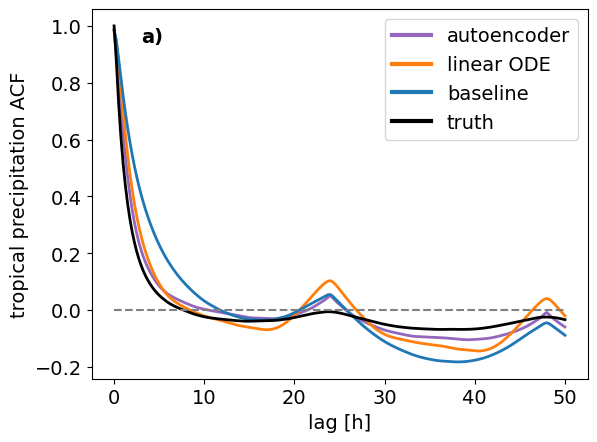

In [119]:
t = (np.arange(max_lag + 1) * 15 / 60)  # time in hours for 15-min steps
line_width = 2
add_nonlin = False
acovs = [ae_mean_acorr, led_mean_acorr, base_mean_acorr, true_mean_acorr]
# ci_lows = [ae_ci_low, led_ci_low, base_ci_low, true_ci_low]
# ci_highs = [ae_ci_high, led_ci_high, base_ci_high, true_ci_high]
labels = ['autoencoder', 'linear ODE', 'baseline', 'truth']
colors = ['tab:purple', 'tab:orange', 'tab:blue', 'black']
if add_nonlin:
    acovs.insert(2, nled_mean_acorr)
    # ci_lows.insert(2, nled_ci_low)
    # ci_highs.insert(2, nled_ci_high)
    labels.insert(2, 'nonlinear ODE')
    colors.insert(2, 'tab:brown')

for acov, label, color in zip(acovs, labels, colors):
    plt.plot(t, acov, label=label, color=color, linewidth=line_width)
    # plt.fill_between(t, ci_low, ci_high, color=color, alpha=0.3)  # error bands are very small due to large sample size, can be omitted for clarity

FS = 14
plt.hlines(0, t[0], t[-1], colors='gray', linestyles='dashed')
plt.xlabel("lag [h]", fontsize=FS)
plt.ylabel("tropical precipitation ACF", fontsize=FS)
plt.tick_params(axis='both', labelsize=FS)
ax = plt.gca()
ax.text(0.1, 0.95, 'a)', ha='left', va='top', fontsize=FS, fontweight='bold', transform=ax.transAxes)
#plt.xlim(0, 24)
leg = plt.legend(fontsize=FS)
for line in leg.legend_handles:
    line.set_linewidth(3)
#plt.savefig(f'plots_paper/DYAMOND_autocorrelation_nonlin={add_nonlin}_long.png', dpi=300, bbox_inches='tight')

### Hyperparameter optimization

In [4]:
import os
tps, ws, dzs, R2s_precip, R2s_predict_upper, R2s_predict_upper_min, R2s_predict_lower, R2s_predict_lower_min = [], [], [], [], [], [], [], []
for file in os.listdir('hyper_opt_precip/'):
    model = torch.load(f'hyper_opt_precip/{file}', weights_only=False, map_location=device)
    print(model.weight_decay, model.latent_dims, file, model.nonlinear_predictability)
    tps.append(model.past_timesteps)
    ws.append(model.weight_decay)
    dzs.append(model.latent_dims)
    R2s_precip.append(max(model.R2).item())
    R2s_predict_upper.append(torch.mean(model.nonlinear_predictability).item())
    R2s_predict_upper_min.append(torch.min(model.nonlinear_predictability).item())
    R2s_predict_lower.append(np.mean(model.linear_predictability))
    R2s_predict_lower_min.append(np.min(model.linear_predictability))

1e-05 6 20260527143050_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=1e-05_eps=1.0.pkl tensor([0.6872, 0.8944, 0.9181, 0.9479, 0.6955, 0.7848])
0.0 8 20260528010951_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=0.0_eps=1.0.pkl tensor([0.3392, 0.2984, 0.4345, 0.8653, 0.8918, 0.7588, 0.4071, 0.4197])
0.0 6 20260527145152_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=0.0_eps=1.0.pkl tensor([0.8479, 0.4993, 0.5921, 0.4666, 0.6020, 0.6949])
1e-05 2 20260527001603_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=1e-05_eps=1.0.pkl tensor([0.5050, 0.6666])
1e-06 2 20260526192321_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=1e-06_eps=1.0.pkl tensor([0.3621, 0.4964])
0.0 2 20260526194107_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=0.0_eps=1.0.pkl tensor([0.7096, 0.4157])
1e-05 4 20260526234615_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=1e-05_eps=1.0.pkl tensor([0.8529, 0.9258, 0.7811, 0.8310])
0.0001 4 

In [5]:
df_DYAMOND = pd.DataFrame([tps, ws, dzs, R2s_precip, R2s_predict_upper, R2s_predict_upper_min, R2s_predict_lower, R2s_predict_lower_min],
             index=['past_timesteps', 'weight_decay', 'latent_dims', 'R2_precip', 'R2_predict_upper', 'R2_predict_upper_min', 'R2_predict_lower', 'R2_predict_lower_min']).T.sort_values('R2_precip', ascending=False)
df_DYAMOND['marker'] = df_DYAMOND.latent_dims.map({2.0: 'o', 4.0: 's', 6.0: '^', 8.0: 'P'})

In [6]:
df_DYAMOND

,past_timesteps,weight_decay,latent_dims,R2_precip,R2_predict_upper,R2_predict_upper_min,R2_predict_lower,R2_predict_lower_min,marker
2,20.0,0.000000,6.0,0.691366,0.617137,0.466613,0.395511,0.236101,^
14,20.0,0.000000,4.0,0.690712,0.821373,0.743180,0.499645,0.288245,s
1,20.0,0.000000,8.0,0.688899,0.551844,0.298418,0.365825,0.047950,P
15,20.0,0.000001,4.0,0.685771,0.826106,0.665702,0.488011,0.356107,s
16,20.0,0.000001,6.0,0.685580,0.732914,0.358778,0.559490,0.174333,^
17,20.0,0.000001,8.0,0.684468,0.699831,0.406824,0.459623,0.177513,P
4,20.0,0.000001,2.0,0.671559,0.429288,0.362133,0.023693,0.013154,o
13,20.0,0.000010,8.0,0.670356,0.749085,0.417310,0.581774,0.179974,P
0,20.0,0.000010,6.0,0.669682,0.821318,0.687151,0.593198,0.238760,^
6,20.0,0.000010,4.0,0.668788,0.847714,0.781124,0.501018,0.341124,s


In [7]:
import os
tps, ws, dzs, R2s_precip, R2s_predict_upper, R2s_predict_upper_min, R2s_predict_lower, R2s_predict_lower_min = [], [], [], [], [], [], [], []
for file in os.listdir('/work/bd1179/b309297/L96/hyper_opt/all_dims_offline_R2/'):
    model = torch.load(f'/work/bd1179/b309297/L96/hyper_opt/all_dims_offline_R2/{file}', weights_only=False, map_location=device)
    tps.append(model.past_timesteps)
    ws.append(model.weight_decay)
    dzs.append(model.latent_dims)
    R2s_precip.append(model.R2[-1])
    R2s_predict_upper.append(np.mean(model.nonlinear_predictability))
    R2s_predict_upper_min.append(np.min(model.nonlinear_predictability))
    R2s_predict_lower.append(np.mean(model.linear_predictability))
    R2s_predict_lower_min.append(np.min(model.linear_predictability))

df_L96 = pd.DataFrame([tps, ws, dzs, R2s_precip, R2s_predict_upper, R2s_predict_upper_min, R2s_predict_lower, R2s_predict_lower_min],
             index=['past_timesteps', 'weight_decay', 'latent_dims', 'R2_precip', 'R2_predict_upper', 'R2_predict_upper_min', 'R2_predict_lower', 'R2_predict_lower_min']).T.sort_values('R2_precip', ascending=False)
df_L96['marker'] = df_L96.latent_dims.map({2.0: 'o', 4.0: 's', 6.0: '^', 8.0: 'P'})
df_L96

,past_timesteps,weight_decay,latent_dims,R2_precip,R2_predict_upper,R2_predict_upper_min,R2_predict_lower,R2_predict_lower_min,marker
15,1000.0,0.000100,8.0,0.937867,0.894698,0.803321,0.815861,0.604839,P
11,1000.0,0.000001,8.0,0.937799,0.861163,0.739908,0.880710,0.794494,P
5,1000.0,0.000100,6.0,0.937052,0.931577,0.885437,0.841895,0.731802,^
3,1000.0,0.000000,6.0,0.936999,0.913012,0.772976,0.853247,0.633954,^
7,1000.0,0.000010,8.0,0.936929,0.927761,0.852215,0.846309,0.610077,P
17,1000.0,0.000010,6.0,0.936124,0.879178,0.784091,0.735785,0.577973,^
14,1000.0,0.000001,6.0,0.934642,0.936299,0.903825,0.861961,0.794038,^
2,1000.0,0.000000,8.0,0.933921,0.928471,0.834617,0.874504,0.725698,P
16,1000.0,0.001000,6.0,0.932172,0.928186,0.828202,0.834477,0.672208,^
9,1000.0,0.000100,4.0,0.931875,0.421492,0.292654,0.320723,0.175380,s


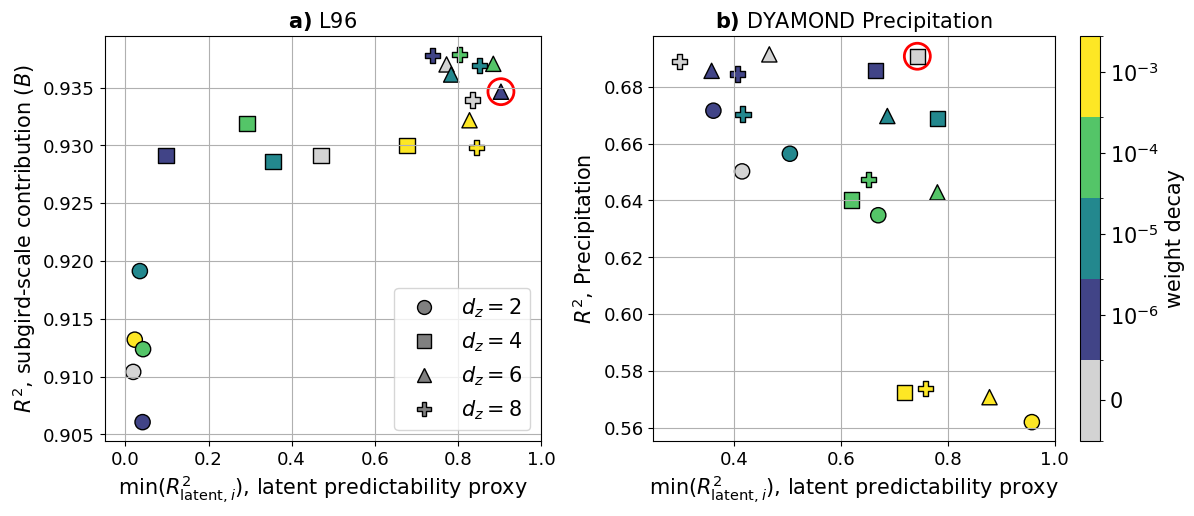

In [9]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
FS = 15
def hyper_opt_figure(df, target, cbar=True, legend=True, fig=None, ax=None):
    markers={2.0:'o', 4.0:'s', 6.0:'^', 8.0:'P'}
    cmap=colors.ListedColormap(['lightgray',*plt.cm.viridis(np.linspace(.2,1,4))])
    bounds=[0, 5e-7, 5e-6, 5e-5, 5e-4, 5e-3]
    norm=colors.BoundaryNorm(bounds,cmap.N)

    if not fig:
        fig,ax=plt.subplots(figsize=(6,5))

    for ld,m in markers.items():
        s=df[df.latent_dims==ld]
        # ax.scatter(s.R2_predict_upper,s.R2_precip,c=s.weight_decay,cmap=cmap,norm=norm,
        ax.scatter(s.R2_predict_upper_min,s.R2_precip,c=s.weight_decay,cmap=cmap,norm=norm,
                marker=m,edgecolor='black',linewidth=1, s=120)

    # highlight target model
    t=df[(df.latent_dims==target['latent_dims'])&
        (df.weight_decay==target['weight_decay'])&
        (df.past_timesteps==target['past_timesteps'])].iloc[0]

    # x,y=t.R2_predict_upper,t.R2_precip
    x,y=t.R2_predict_upper_min,t.R2_precip
    ax.scatter(x,y,s=350,facecolors='none',edgecolors='red',linewidths=2,zorder=0)

    if cbar:
        cb=plt.colorbar(ScalarMappable(norm=norm,cmap=cmap),ax=ax)
        cb.set_ticks([2.5e-7, 3e-6, 3e-5, 3e-4, 3e-3])
        cb.set_ticklabels(['0',r'$10^{-6}$',r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'], fontsize=FS)
        cb.set_label('weight decay', fontsize=FS)
    if legend:
        ax.legend(handles=[
            Line2D([0],[0],marker=m,linestyle='None',color='none',
                markerfacecolor='gray',markeredgecolor='black', markersize=10,
                label=rf'$d_z={{{int(ld)}}}$')
            for ld,m in markers.items()
        ],loc='lower right',frameon=True, fontsize=FS)

    ax.set_xlabel(r'$\min(R^2_{\text{latent},i})$, latent predictability proxy', fontsize=FS)
    # ax.set_xlabel(r'$\bar R^2$, upper predictability bound', fontsize=FS)
    ax.set_ylabel(r'$R^2$, Precipitation', fontsize=FS)
    ax.grid()
    ax.set_xlim(-.05, 1.0)
    ax.tick_params(axis='both', which='major', labelsize=FS-2)
    plt.tight_layout()

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.15]})
hyper_opt_figure(df_DYAMOND, dict(latent_dims=4.0,weight_decay=0.0,past_timesteps=20.0), True, False, fig, ax1)
hyper_opt_figure(df_L96, dict(latent_dims=6.0,weight_decay=1.e-6,past_timesteps=1000.0), False, True, fig, ax2)
ax1.set(xlim=(.25, 1.0))
ax1.set_title(r'$\mathbf{b)}$ DYAMOND Precipitation', fontsize=FS)
ax2.set_title(r'$\mathbf{a)}$ L96', fontsize=FS)
ax2.set_ylabel(r'$R^2$, subgird-scale contribution ($B$)', fontsize=FS)
plt.savefig('plots_paper/hyper_opt.png', dpi=300, bbox_inches='tight')

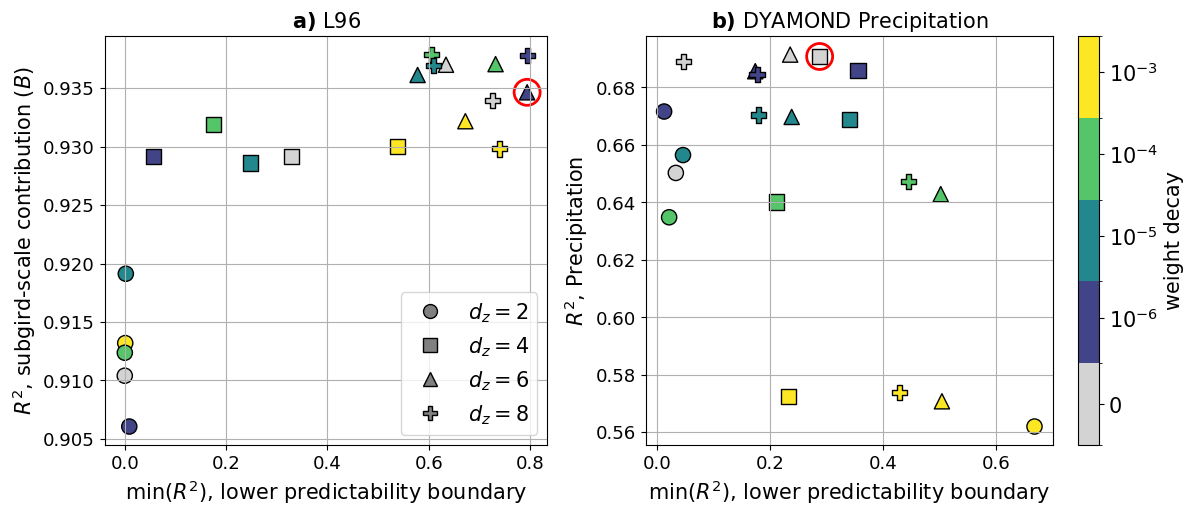

In [10]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
FS = 15
def hyper_opt_figure(df, target, cbar=True, legend=True, fig=None, ax=None):
    markers={2.0:'o', 4.0:'s', 6.0:'^', 8.0:'P'}
    cmap=colors.ListedColormap(['lightgray',*plt.cm.viridis(np.linspace(.2,1,4))])
    bounds=[0, 5e-7, 5e-6, 5e-5, 5e-4, 5e-3]
    norm=colors.BoundaryNorm(bounds,cmap.N)

    if not fig:
        fig,ax=plt.subplots(figsize=(6,5))

    for ld,m in markers.items():
        s=df[df.latent_dims==ld]
        ax.scatter(s.R2_predict_lower_min,s.R2_precip,c=s.weight_decay,cmap=cmap,norm=norm,
                marker=m,edgecolor='black',linewidth=1, s=120)

    # highlight target model
    t=df[(df.latent_dims==target['latent_dims'])&
        (df.weight_decay==target['weight_decay'])&
        (df.past_timesteps==target['past_timesteps'])].iloc[0]

    x,y=t.R2_predict_lower_min,t.R2_precip
    ax.scatter(x,y,s=350,facecolors='none',edgecolors='red',linewidths=2,zorder=0)

    if cbar:
        cb=plt.colorbar(ScalarMappable(norm=norm,cmap=cmap),ax=ax)
        cb.set_ticks([2.5e-7, 3e-6, 3e-5, 3e-4, 3e-3])
        cb.set_ticklabels(['0',r'$10^{-6}$',r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'], fontsize=FS)
        cb.set_label('weight decay', fontsize=FS)
    if legend:
        ax.legend(handles=[
            Line2D([0],[0],marker=m,linestyle='None',color='none',
                markerfacecolor='gray',markeredgecolor='black', markersize=10,
                label=rf'$d_z={{{int(ld)}}}$')
            for ld,m in markers.items()
        ],loc='lower right',frameon=True, fontsize=FS)

    ax.set_xlabel(r'$\min(R^2)$, lower predictability boundary', fontsize=FS)
    ax.set_ylabel(r'$R^2$, Precipitation', fontsize=FS)
    ax.grid()
    #ax.set_xlim(0, 1.0)
    ax.tick_params(axis='both', which='major', labelsize=FS-2)
    plt.tight_layout()

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.15]})
hyper_opt_figure(df_DYAMOND, dict(latent_dims=4.0,weight_decay=0.0,past_timesteps=20.0), True, False, fig, ax1)
hyper_opt_figure(df_L96, dict(latent_dims=6.0,weight_decay=1.e-6,past_timesteps=1000.0), False, True, fig, ax2)
#ax1.set(xlim=(.25, 1.0))
ax1.set_title(r'$\mathbf{b)}$ DYAMOND Precipitation', fontsize=FS)
ax2.set_title(r'$\mathbf{a)}$ L96', fontsize=FS)
ax2.set_ylabel(r'$R^2$, subgird-scale contribution ($B$)', fontsize=FS)
plt.savefig('plots_paper/hyper_opt_lower.png', dpi=300, bbox_inches='tight')

### Initial past timesteps hyper parameter optimization

In [1]:
import pandas as pd
import os

In [3]:
pts, dzs, losses, preds = [], [], [], []
for file in os.listdir('initial_pt_hyper_opt/'):
    if 'pkl' in file:
        model = torch.load('initial_pt_hyper_opt/' + file, map_location='cpu', weights_only=False)
        pts.append(model.past_timesteps)
        dzs.append(model.latent_dims)
        losses.append(max(model.R2))
        preds.append(np.mean(model.nonlinear_predictability.detach().cpu().numpy()))

df = pd.DataFrame(np.array([pts, dzs, losses]).T, columns=['M', 'd_z', 'test loss'])
df = df.sort_values(['d_z', 'M'])
# Format the columns as requested
df['M'] = df['M'].astype(int)           # M as integer
df['d_z'] = df['d_z'].astype(int)       # d_z as integer
df['test loss'] = df['test loss'].map('{:.3f}'.format)  # 3 decimal places
#df['upper predictability boundary R^2'] = df['upper predictability boundary R^2'].map('{:.2f}'.format)  # 2 decimal places

df.to_latex('initial_pt_hyper_opt/summary_latex_table', index=False)
df

,M,d_z,test loss
5,3,4,0.644
1,5,4,0.674
3,10,4,0.686
4,20,4,0.691
0,3,8,0.648
2,5,8,0.674
7,10,8,0.690
6,20,8,0.689


### Nonlinear ODE before/after rollout training

### Spatial precipitation error

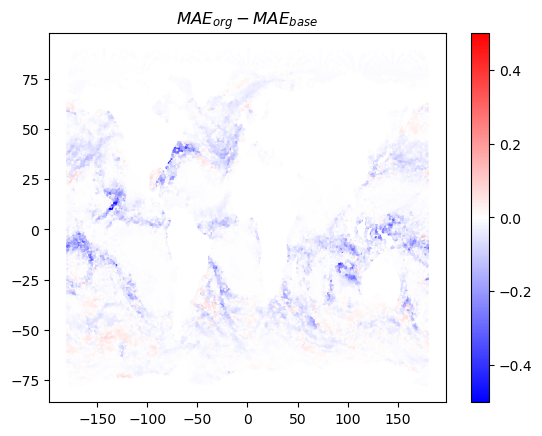

In [6]:
MSE_base = np.mean(np.absolute(precip_base - precip_base_pred), axis=1)
MSE_org = np.mean(np.absolute(precip_org - precip_org_pred), axis=1)

vmin, vmax = -.5, .5#-200, 200
im = plt.scatter(lon[coord_base], lat[coord_base], c=MSE_org - MSE_base, vmin=vmin, vmax=vmax, cmap='bwr', s=1)
plt.title(r'$MAE_{org} - MAE_{base}$')
plt.colorbar(im)

Text(0.5, 1.0, 'precip accumulated')

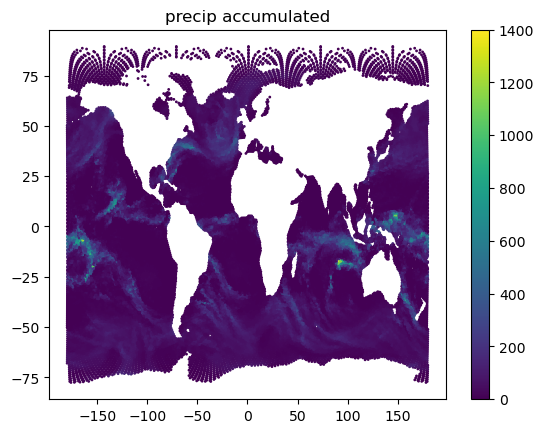

In [7]:
precip_acc = np.sum(precip_org, axis=1)
im = plt.scatter(lon[coord_org], lat[coord_org], c=precip_acc, vmin=0, vmax=1400, cmap='viridis', s=1)
plt.colorbar(im)
plt.title('precip accumulated')

### Precip timeseries

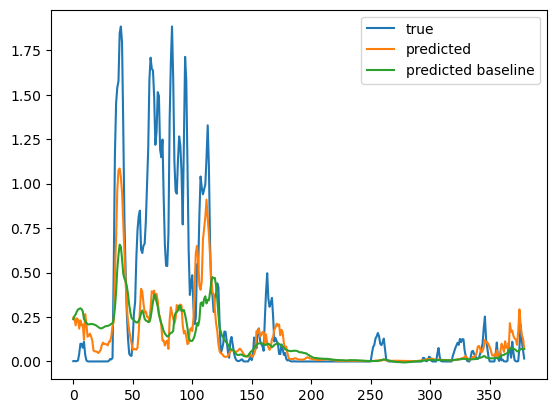

In [42]:
coord = np.random.randint(0, precip_org.shape[0])
plt.plot(precip_org[coord], label='true')
plt.plot(precip_org_pred[coord], label='predicted')
plt.plot(precip_base_pred[coord, 10:], label='predicted baseline')
#plt.plot(precip_base[coord, 10:], label='true baseline')
plt.legend()

In [2]:
def plot_loss(model, color='tab:blue', label=None, ax=None):
    if ax is None:
        fix, ax = plt.subplots()
    ax.plot(model.train_loss, color=color, linestyle='--')
    ax.plot(model.val_loss, color=color, linestyle='-', label=label)
    print(min(model.test_loss))

### Precip Histogram

In [ ]:
# model_ConvNN = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251105161233_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
# model_base = torch.load('networks/NNbase/n_features=6_memory_indices=None_latent_dims=0_past_timesteps=0/20251107135137_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
ds = get_standardized_ds()

past_timesteps = 10
latent_dims = 5
n_features = 6
kernel_size= 3
memory_indices = [0, 1, 2, 3, 4, 5]

In [4]:
model_base = torch.load('networks/NNbase/n_features=6_memory_indices=None_latent_dims=0_past_timesteps=0/20251107135137_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_3 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=3/20251107200823_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_10 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251107204236_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_20 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=20/20251108002837_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)

In [5]:
_, valloader, _ = get_dataloader(ds, share_val=.1)
for model in [model_base, model_3, model_10, model_20]:
    model.X = ds
    model.X = model.X.to(device)

# model_ConvNN.X = ds
# model_ConvNN.X = model_ConvNN.X.to(device)

# model_base.X = ds
# model_base.X = model_base.X.to(device)

In [39]:
def predict_precip(model, valloader):
    # Predict precip on val set and collect targets
    model.eval()
    Pr, Pr_pred = [], []
    with torch.no_grad():
        for coords in valloader:
            # Preprocessing
            x_present, x_past, y = preprocess(model.X, coords, model.past_timesteps)

            # Precip
            if model.model_name in ['NNbase']:
                y_pred = model.forward(x_present)[0].detach().cpu()
            elif model.model_name in ['NNpAEpD', 'ConvNN+AE+D']:
                y_pred = model.forward(x_past, x_present)[0].detach().cpu()

            Pr_pred.append(y_pred)
            Pr.append(y.detach().cpu())
    Pr = torch.cat(Pr, dim=0)
    Pr_pred = torch.cat(Pr_pred, dim=0)
    return Pr, Pr_pred

Pr, Pr_pred_base = predict_precip(model_base, valloader)
Pr, Pr_pred_m3 = predict_precip(model_3, valloader)
Pr, Pr_pred_m10 = predict_precip(model_10, valloader)
Pr, Pr_pred_m20 = predict_precip(model_20, valloader)

In [40]:
mean, std = xr.load_dataarray('merged_DYAMOND_variable_mean.nc').values[-1], xr.load_dataarray('merged_DYAMOND_variable_std.nc').values[-1]
print(mean, std)

0.12761723 0.5849325


In [43]:
Pr_hist, bins = np.histogram(Pr.detach().cpu().numpy().flatten() * std + mean, bins=80, density=True)
Pr_hists = [Pr_hist]

for Pr_mod in [Pr_pred_base, Pr_pred_m3, Pr_pred_m10, Pr_pred_m20]:
    Pr_mod = Pr_mod * std + mean
    Pr_hist, _ = np.histogram(Pr_mod.detach().cpu().numpy().flatten(), bins=bins, density=True)
    Pr_hists.append(Pr_hist)

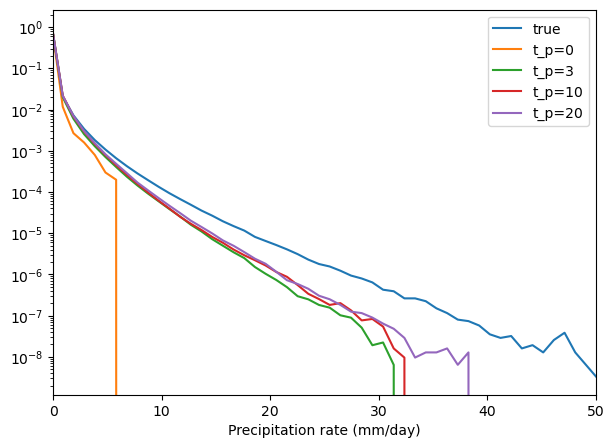

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for hist, tp in zip(Pr_hists, ['true', 't_p=0', 't_p=3', 't_p=10', 't_p=20']):
    ax.plot(bins[:-1], hist, label=tp)
ax.set(yscale='log', xlim=(0, 50), xlabel='Precipitation rate (mm/day)')
ax.legend()
pass

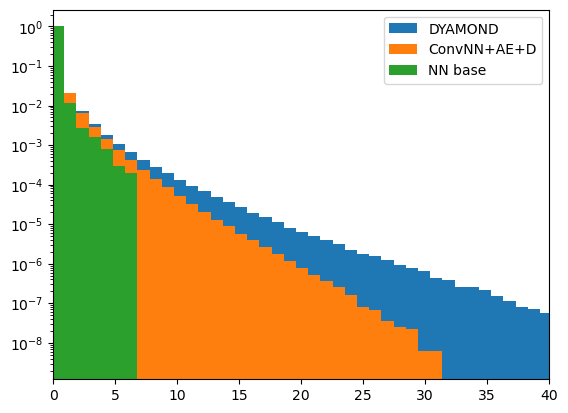

In [16]:
Pr_flatt = Pr.detach().cpu().numpy().flatten() * std + mean
_, bins, _ = plt.hist(Pr_flatt, bins=80, density=True, log=True, label='DYAMOND');

Pr_flatt = Pr_pred_ConvNN.detach().cpu().numpy().flatten() * std + mean
plt.hist(Pr_flatt, bins=bins, density=True, log=True, label='ConvNN+AE+D');

Pr_flatt = Pr_pred_base.detach().cpu().numpy().flatten() * std + mean
plt.hist(Pr_flatt, bins=bins, density=True, log=True, label='NN base');

plt.xlim(0, 40)
plt.legend()

(array([1.72554312e+00, 7.44247820e-02, 3.37560146e-02, 1.81773734e-02,
        1.11704742e-02, 7.50521744e-03, 5.35743960e-03, 3.92680389e-03,
        2.93544780e-03, 2.26427663e-03, 1.78575369e-03, 1.42140622e-03,
        1.13658941e-03, 9.17194249e-04, 7.48826060e-04, 6.10205258e-04,
        5.06169737e-04, 4.16885920e-04, 3.46001568e-04, 2.89012024e-04,
        2.40710455e-04, 1.99900777e-04, 1.68796637e-04, 1.40269390e-04,
        1.20911615e-04, 1.00096180e-04, 8.64215456e-05, 7.35026462e-05,
        6.36126367e-05, 5.36809724e-05, 4.67901839e-05, 3.91315901e-05,
        3.31690212e-05, 2.91225672e-05, 2.47904812e-05, 2.19163088e-05,
        1.84470696e-05, 1.60727532e-05, 1.46624450e-05, 1.19905952e-05,
        1.03541616e-05, 9.02716275e-06, 7.80132522e-06, 6.94442909e-06,
        6.33746099e-06, 5.50436753e-06, 4.95095544e-06, 4.42731270e-06,
        3.61800590e-06, 3.33237386e-06, 2.99318580e-06, 2.54688573e-06,
        2.29695769e-06, 1.86850963e-06, 1.77329894e-06, 1.559074

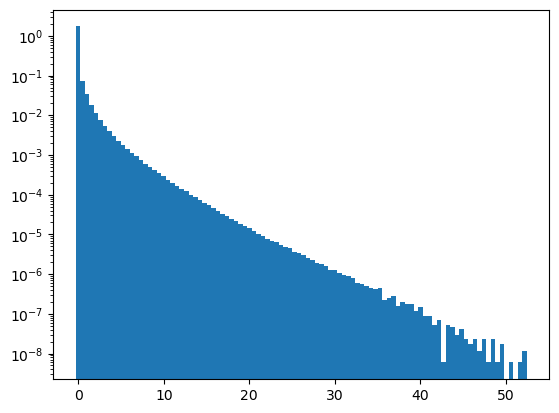

In [32]:
Pr_flatt = Pr_pred_ConvNN.detach().cpu().numpy().flatten()
plt.hist(Pr_flatt, bins=100, density=True, log=True)

In [43]:
#  Rescale
normalization_factor = xr.load_dataarray('merged_DYAMOND_variable_normalization_factor.nc').values[-1]
Pr, Pr_pred_ConvNN = Pr * normalization_factor, Pr_pred_ConvNN * normalization_factor
Pr_pred_ConvNN_trigger = Pr_pred_ConvNN_trigger * normalization_factor

In [33]:
0.05 / normalization_factor

np.float32(0.000636013)

In [44]:
Pr_hist, bins = np.histogram(Pr, bins=100, density=True)
Pr_pred_ConvNN_hist, _ = np.histogram(Pr_pred_ConvNN, bins=bins, density=True)
Pr_pred_ConvNN_trigger_hist, _ = np.histogram(Pr_pred_ConvNN_trigger, bins=bins, density=True)

In [14]:
# Pr, Pr_pred = Pr.numpy().flatten(), Pr_pred.numpy().flatten()
# Pr, Pr_pred_base, Pr_pred_ConvNN = Pr.flatten(), Pr_pred_base.flatten(), Pr_pred_ConvNN.flatten()
# ds_mean = xr.load_dataarray('merged_DYAMOND_variable_mean.nc')
# ds_std = xr.load_dataarray('merged_DYAMOND_variable_std.nc')
# Pr_pred_ConvNN_rescaled = Pr_pred_ConvNN * ds_std.values[-1] + ds_mean.values[-1]

# Pr_hist, bins = np.histogram(Pr, bins=100, density=True)
# Pr_pred_base_hist, _ = np.histogram(Pr_pred_base, bins=bins, density=True)
# Pr_pred_ConvNN_hist, _ = np.histogram(Pr_pred_ConvNN_rescaled, bins=bins, density=True)

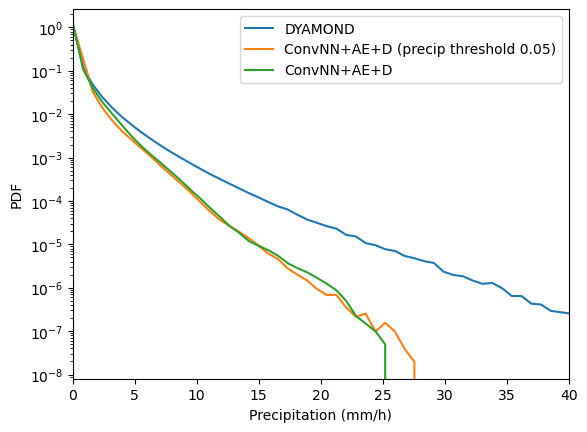

In [47]:
plt.plot(bins[:-1], Pr_hist, label='DYAMOND', color='tab:blue')
plt.plot(bins[:-1], Pr_pred_ConvNN_trigger_hist, label='ConvNN+AE+D (precip threshold 0.05)', color='tab:orange')
plt.plot(bins[:-1], Pr_pred_ConvNN_hist, label='ConvNN+AE+D', color='tab:green')
plt.yscale('log')
plt.xlabel('Precipitation (mm/h)')
plt.ylabel('PDF')
plt.xlim(0, 40)
plt.legend()

### Eval reconstruction loss

In [7]:
from training_gpu import get_standardized_ds

In [8]:
ds = get_standardized_ds('global', 'ocean_land', rescale_precip=False)
ds

(8, 3897, 81920)


tensor([[[-1.4116e+00, -1.3922e+00, -1.4148e+00,  ..., -5.7732e-01,
          -3.6179e-01, -6.0086e-01],
         [-1.4151e+00, -1.3975e+00, -1.4160e+00,  ..., -5.6003e-01,
          -3.4510e-01, -5.8291e-01],
         [-1.4162e+00, -1.4003e+00, -1.4151e+00,  ..., -5.4212e-01,
          -3.2678e-01, -5.6638e-01],
         ...,
         [-1.4376e+00, -1.4519e+00, -1.4309e+00,  ..., -1.4257e-01,
          -1.5682e-01, -2.2748e-01],
         [-1.4377e+00, -1.4524e+00, -1.4310e+00,  ..., -1.4139e-01,
          -1.5665e-01, -2.1805e-01],
         [-1.4375e+00, -1.4526e+00, -1.4310e+00,  ..., -1.4054e-01,
          -1.5669e-01, -2.0873e-01]],

        [[-1.2066e+00, -1.2116e+00, -1.1960e+00,  ...,  5.3772e-01,
           6.3394e-01,  5.1326e-01],
         [-1.2059e+00, -1.2108e+00, -1.1953e+00,  ...,  5.5646e-01,
           6.3927e-01,  5.3358e-01],
         [-1.2041e+00, -1.2089e+00, -1.1936e+00,  ...,  6.0786e-01,
           6.4486e-01,  5.4986e-01],
         ...,
         [-1.2322e+00, -1

In [33]:
#model_decoder = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251103181446_global_oceanland_threshold=0.0_kernel=3_alpha=0.7.pkl', weights_only=False)
#model_decoder = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251104132641_global_oceanland_threshold=0.0_kernel=3_alpha=1.0.pkl', weights_only=False)
model_decoder = torch.load('networks/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2]_latent_dims=3_past_timesteps=20/20260114181941_global_ocean_land_rp=False_alpha=75.0_lr=0.001_weigth_decay=0.0_eps=1.0.pkl', weights_only=False, map_location=device)
model_decoder.X = ds 
model_decoder.X = model_decoder.X.to(device)

In [34]:
_, valloader, _ = get_dataloader(ds, share_val=.1, batch_size=1)

Nsamples = 5
Ncoords = valloader.dataset.__len__()
coords = np.random.randint(0, Ncoords, size=Nsamples)
coords

array([ 5909, 25206, 46637, 18250, 35757])

In [35]:
def reconstruct_input(model, valloader, Nsamples=1):
    # Predict precip on val set and collect targets
    model.eval()
    X_past, X_past_rec = [], []
    with torch.no_grad():
        Ncoords = valloader.dataset.__len__()
        coords = np.random.randint(0, Ncoords, size=Nsamples)
        # Preprocessing
        x_present, x_past, _ = preprocess(model.X, coords, model.past_timesteps, model.n_features, 
                                          valloader.dataset.tstart, valloader.dataset.tend, 
                                          model.memory_indices)

        # Reconstruct
        x_past_rec = model.forward(x_past, x_present)[1].detach().cpu()

        X_past_rec.append(x_past_rec)
        X_past.append(x_past.detach().cpu())
    X_past = torch.cat(X_past, dim=0).detach().cpu().numpy()
    X_past_rec = torch.cat(X_past_rec, dim=0).detach().cpu().numpy()
    return X_past, X_past_rec

def R2_reconstruction(model, valloader):
    X_past, X_past_rec = reconstruct_input(model, valloader, Nsamples=1000)
    for var in range(3):
        x, y = X_past[:, var, :].flatten(), X_past_rec[:, var, :].flatten()
        r2 = R2Score()
        x, y = torch.tensor(x), torch.tensor(y)
        print(torch.nn.MSELoss()(x, y))
        r2_score = r2(x, y)
        print(f'Variable {var}: R2 = {r2_score.item()}')

R2_reconstruction(model_decoder, valloader)

tensor(0.0012)
Variable 0: R2 = 0.9987523555755615
tensor(0.0013)
Variable 1: R2 = 0.9986123442649841
tensor(0.0013)
Variable 2: R2 = 0.9985873699188232


Text(0, 0.5, 'Feature 0')

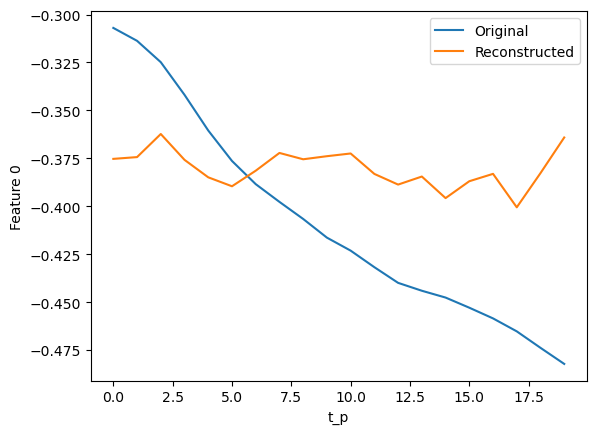

In [76]:
X_past, X_past_rec = reconstruct_input(model_decoder, valloader)
var = 0
plt.plot(X_past[150, var, :], label='Original')
plt.plot(X_past_rec[150, var, :], label='Reconstructed')
plt.legend()
#plt.ylim(-2, 2)
plt.xlabel('t_p')
plt.ylabel(f'Feature {var}')

In [148]:
X_past.shape

(370, 7, 20)

Text(0, 0.5, 'Feature 0 at t_p=19')

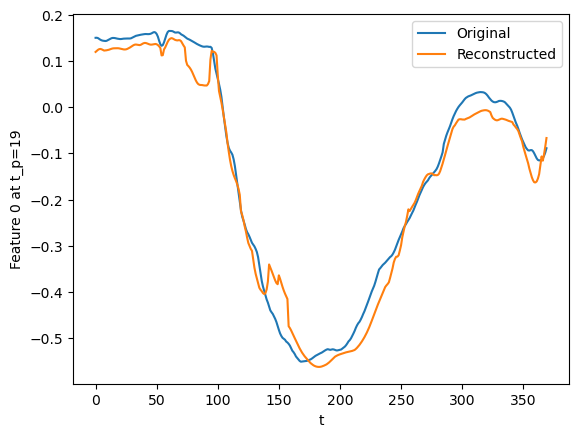

In [77]:
var = 0
pt = 19
plt.plot(X_past[:, var, pt], label='Original')
plt.plot(X_past_rec[:, var, pt], label='Reconstructed')
plt.legend()
plt.xlabel('t')
plt.ylabel(f'Feature {var} at t_p={pt}')

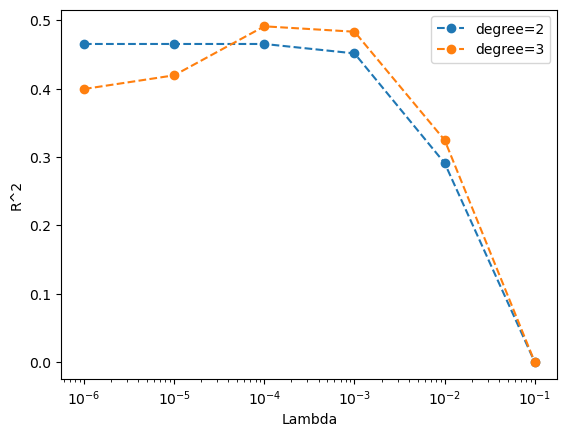

In [5]:
lambdas_scores = np.load('SINDy_ODEs/degree=2/20251215092753_global_ocean_land_rp=False_eps=1.0_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
lambdas_scores
plt.plot(lambdas_scores[:, 0], lambdas_scores[:, 1], marker='o', linestyle='--', label='degree=2')

lambdas_scores = np.load('SINDy_ODEs/degree=3/20251215092753_global_ocean_land_rp=False_eps=1.0_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
lambdas_scores
plt.plot(lambdas_scores[:, 0], lambdas_scores[:, 1], marker='o', linestyle='--', label='degree=3')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('R^2')
plt.legend()

### Training speed and learning rate

In [3]:
path001 = 'networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251104191301_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl'
path002 = 'networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251104201146_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.002.pkl'
path005 = 'networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251104210902_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.005.pkl'
path01 = 'networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251104220616_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.01.pkl'

model_001 = torch.load(path001, weights_only=False, map_location=device)
model_002 = torch.load(path002, weights_only=False, map_location=device)
model_005 = torch.load(path005, weights_only=False, map_location=device)
model_01 = torch.load(path01, weights_only=False, map_location=device)

0.18575929829811777
0.19424453401182973
0.20754378382925437
0.3426332911978534


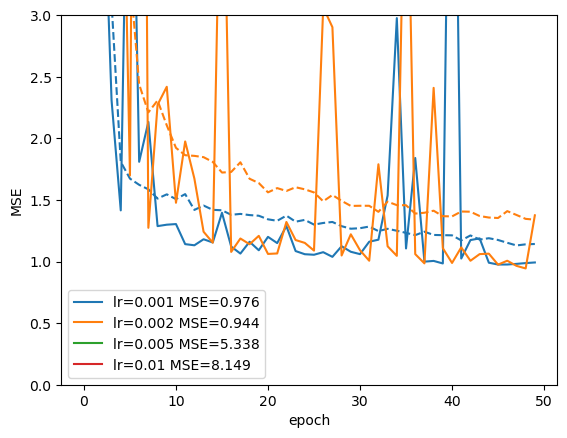

In [10]:
fig, ax = plt.subplots(1, 1)

for model, c in zip([model_001, model_002, model_005, model_01], ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']):
    plot_loss(model, color=c, label=f'lr={model.learning_rate} MSE={round(min(model.val_loss), 3)}', ax=ax)

ax.set(xlabel='epoch', ylabel='MSE', ylim=(0, 3))
plt.legend()

### Standardize training data

In [ ]:
def plot_distribution(data, labels, skw):

    N = len(data)
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()

    ax2.plot(np.arange(N + 2), np.zeros(N + 2), ":r")
    ax1.boxplot(data, labels=labels, sym="", medianprops={"color": "k"})

    ymax = []
    for i in range(N):
        y = skw[i]
        x = i + 1
        ax2.plot(x, y, "*r", ms=10, markeredgecolor="k")
        ymax.append(np.max(data[i]))

    # ylims
    ylims = np.percentile(ymax, 50)
    ax1.set_ylim((-1 * ylims, ylims))
    ylims = np.max(np.abs(skw))
    ax2.set_ylim((-1.1 * ylims, 1.1 * ylims))

    # labels
    ax1.set_ylabel(r"Standardized values [$\sigma$]")
    ax2.set_ylabel(r"Skewness []", color="r")
    ax2.tick_params(axis="y", labelcolor="r")

In [21]:
from parametrizations import load_DYAMOND_data
ds = load_DYAMOND_data()
ds = np.array(ds[['huss', 'prw', 'tas', 'ts', 'hfss', 'hfls', 'is_land', 'precip']].to_array())

In [22]:
from scipy.stats import boxcox, skew

In [3]:
type(ds)

numpy.ndarray

In [35]:
precip = ds[-1].flatten()
print(precip.shape)
precip_filter = precip[precip > .0]
print(precip_filter.shape)

(319242240,)
(171685378,)


In [36]:
precip_filter.shape[0] / precip.shape[0]

0.5377902936653997

(array([1.0000000e+00, 0.0000000e+00, 1.0000000e+00, 1.0000000e+00,
        2.0000000e+00, 3.0000000e+00, 5.0000000e+00, 8.0000000e+00,
        2.9000000e+01, 5.1000000e+01, 6.5000000e+01, 1.0700000e+02,
        2.2200000e+02, 3.8700000e+02, 1.0650000e+03, 1.5950000e+03,
        3.5750000e+03, 6.8960000e+03, 2.5546000e+04, 4.3274000e+04,
        9.7333000e+04, 1.9484200e+05, 6.1092100e+05, 1.3638150e+06,
        3.2013190e+06, 6.9910950e+06, 1.1655271e+07, 1.3001335e+07,
        1.6415157e+07, 2.0043269e+07, 2.2552223e+07, 2.1951287e+07,
        1.8867107e+07, 1.4729716e+07, 1.0495764e+07, 6.2437710e+06,
        2.5807310e+06, 5.6632200e+05, 4.0869000e+04, 3.9800000e+02]),
 array([-30.07877174, -29.21768846, -28.35660519, -27.49552191,
        -26.63443864, -25.77335536, -24.91227208, -24.05118881,
        -23.19010553, -22.32902226, -21.46793898, -20.60685571,
        -19.74577243, -18.88468915, -18.02360588, -17.1625226 ,
        -16.30143933, -15.44035605, -14.57927278, -13.7181895 

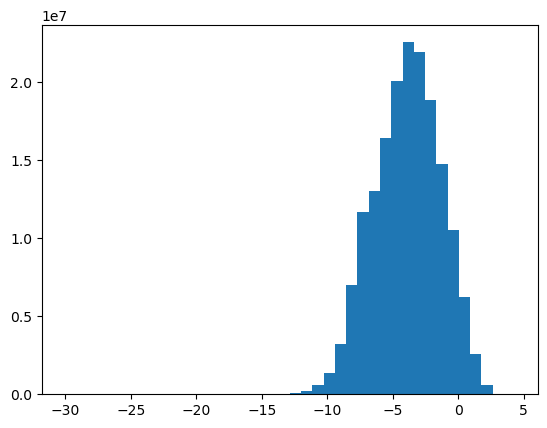

In [32]:
plt.hist(np.log(precip_filter), bins=40)

In [5]:
print('resclaing precip ...')
precip = ds[-1]
print('get mask')
neg_mask = np.where(precip < 0.0)
print('apply mask', precip.shape, neg_mask[0].shape, neg_mask[1].shape)

precip[neg_mask] = 0.0
print('compute log')
ds[-1] = np.log(1.e-6 + precip)

resclaing precip ...
get mask
apply mask (3897, 81920) (176947,) (176947,)
compute log


In [4]:
precip = ds[-1]

neg_mask_bool = precip < 0.0
precip[neg_mask_bool] = 0.0

# 3. Compute the log and assign it back to the DataArray (ds[-1])
# Dask/Xarray handles this operation lazily and chunk-by-chunk.
ds[-1] = np.log(1.e-6 + precip)

In [ ]:
precip = ds[-1]
neg_mask = np.where(precip < 0.0)
precip[neg_mask] = 0.0
ds[-1] = np.log(1.e-6 + precip)

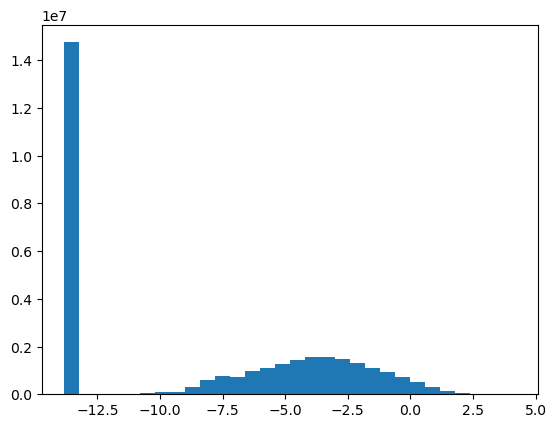

In [9]:
precip = ds[-1].flatten()[::10]
plt.hist(np.log(precip + 1.e-6), bins=30);

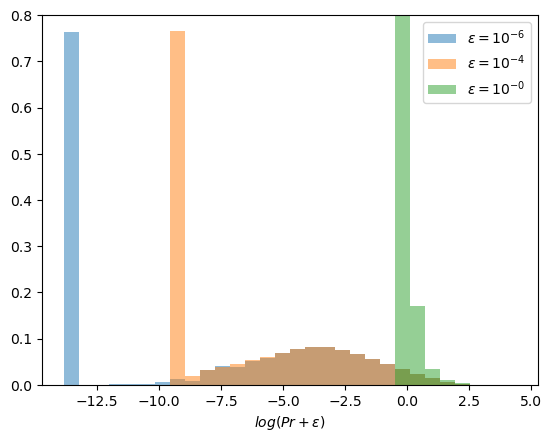

In [125]:
precip = ds[-1].flatten()[::]
precip[precip < 0.0] = 0
precip = precip #+ 1.e-9 # - precip.min() + 1.e-6
_, bins, _ = plt.hist(np.log(precip + 1.e-6), label=r'$\epsilon = 10^{-6}$', bins=30, alpha=0.5, density=True)
plt.hist(np.log(precip + 1.e-4), label=r'$\epsilon = 10^{-4}$', bins=bins, alpha=0.5, density=True)
plt.hist(np.log(precip + 1.e-0), label=r'$\epsilon = 10^{-0}$', bins=bins, alpha=0.5, density=True)
plt.xlabel(r'$log(Pr + \epsilon)$')
plt.ylim(0, .8)
plt.legend()

In [122]:
precip = precip + 1.e-9

In [123]:
data = []
labels = []
skw = []
precip = precip
# Test a range of values for the transformation parameter Lambda
Lambdas = np.linspace(-0.2, 0.2, 11)
for i, Lambda in enumerate(Lambdas):
    #R_, _ = transformation.boxcox_transform(R, metadata, Lambda)
    R_ = boxcox(precip, Lambda)
    R_ = (R_ - np.mean(R_)) / np.std(R_)
    data.append(R_)
    labels.append("{0:.2f}".format(Lambda))
    skw.append(skew(R_))  # skewness

/tmp/ipykernel_78794/2023011954.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(data, labels=labels, sym="", medianprops={"color": "k"})


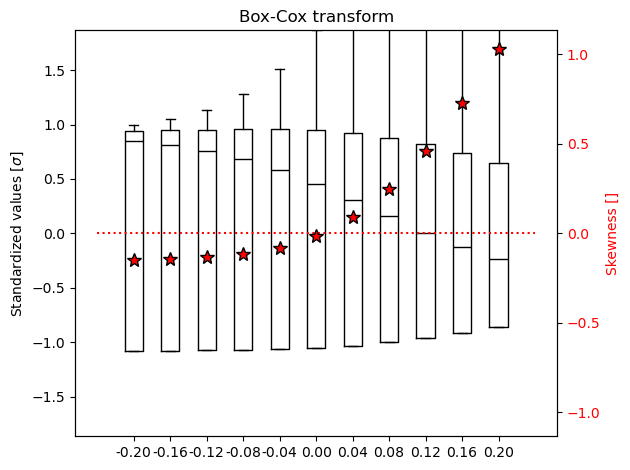

Best parameter lambda: 0.00
(skewness = -0.02)


In [124]:
# Plot the transformed data distribution as a function of lambda
plot_distribution(data, labels, skw)
plt.title("Box-Cox transform")
plt.tight_layout()
plt.show()

# Best lambda
idx_best = np.argmin(np.abs(skw))
Lambda = Lambdas[idx_best]

print("Best parameter lambda: %.2f\n(skewness = %.2f)" % (Lambda, skw[idx_best]))

(array([1.475419e+07, 6.950000e+02, 1.040000e+03, 1.617000e+03,
        8.770000e+02, 2.774000e+03, 1.649000e+03, 4.874000e+03,
        1.747000e+03, 2.973000e+03, 9.266000e+03, 5.726000e+03,
        3.617000e+03, 1.890500e+04, 9.135000e+03, 2.941300e+04,
        1.279700e+04, 2.366800e+04, 8.739300e+04, 4.086400e+04,
        1.759620e+05, 5.473600e+04, 1.026490e+05, 4.187140e+05,
        1.799430e+05, 4.637740e+05, 3.345810e+05, 4.114950e+05,
        4.829500e+05, 5.083790e+05, 6.134620e+05, 6.750220e+05,
        7.856610e+05, 8.725950e+05, 9.779440e+05, 1.073699e+06,
        1.143944e+06, 1.169587e+06, 1.148500e+06, 1.099135e+06,
        1.011184e+06, 8.969730e+05, 7.782730e+05, 6.298110e+05,
        4.613590e+05, 2.810630e+05, 1.236560e+05, 3.235600e+04,
        3.514000e+03, 8.300000e+01]),
 array([-1.04349146e+00, -9.88497073e-01, -9.33502687e-01, -8.78508302e-01,
        -8.23513916e-01, -7.68519530e-01, -7.13525145e-01, -6.58530759e-01,
        -6.03536374e-01, -5.48541988e-01, 

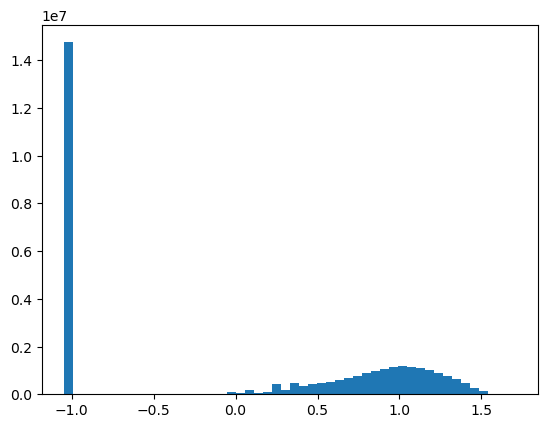

In [78]:
plt.hist(data[idx_best], bins=50)

In [64]:
R_rescale, Lambda = boxcox(precip)

In [65]:
Lambda

np.float64(-0.03408913869337523)

(array([1.4754634e+07, 1.2230000e+03, 1.7580000e+03, 3.1980000e+03,
        1.8440000e+03, 5.1890000e+03, 3.4040000e+03, 9.7050000e+03,
        6.4650000e+03, 1.7368000e+04, 7.7060000e+03, 1.3142000e+04,
        3.4760000e+04, 2.5644000e+04, 9.0289000e+04, 4.7846000e+04,
        1.8956400e+05, 9.5896000e+04, 4.2321700e+05, 1.8482100e+05,
        4.5846300e+05, 3.4421700e+05, 4.2401500e+05, 4.7144200e+05,
        5.1593300e+05, 6.0031300e+05, 6.5178300e+05, 7.3111200e+05,
        8.0370400e+05, 8.8206000e+05, 9.5076000e+05, 9.9698800e+05,
        1.0181210e+06, 1.0037880e+06, 9.6381400e+05, 9.1024200e+05,
        8.3761500e+05, 7.4917900e+05, 6.6380400e+05, 5.7486800e+05,
        4.7706600e+05, 3.7648100e+05, 2.7283500e+05, 1.7615500e+05,
        9.5255000e+04, 4.0864000e+04, 1.2904000e+04, 2.4990000e+03,
        2.6400000e+02, 7.0000000e+00]),
 array([-17.64576975, -17.21479178, -16.78381381, -16.35283584,
        -15.92185786, -15.49087989, -15.05990192, -14.62892395,
        -14.1979

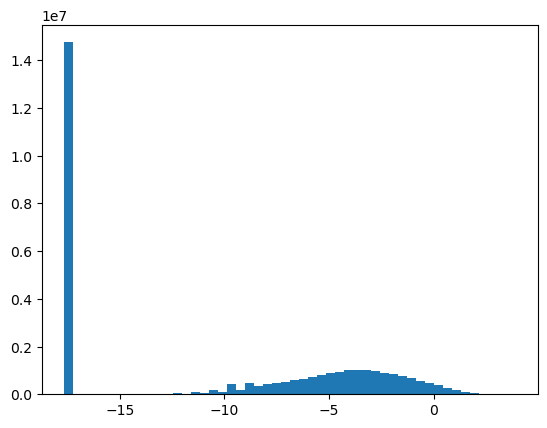

In [66]:
plt.hist(R_rescale, bins=50)

(array([1.4753495e+07, 6.5000000e+01, 8.8000000e+01, 1.3500000e+02,
        2.9700000e+02, 5.0900000e+02, 8.6500000e+02, 5.9800000e+02,
        2.2110000e+03, 3.6850000e+03, 7.0810000e+03, 1.2545000e+04,
        2.3012000e+04, 1.8561000e+04, 5.2395000e+04, 1.1677300e+05,
        2.2731300e+05, 5.0380400e+05, 2.9370800e+05, 7.6722000e+05,
        7.2170300e+05, 9.4364600e+05, 1.0356220e+06, 1.1768490e+06,
        1.3481680e+06, 1.4641660e+06, 1.4983550e+06, 1.4289550e+06,
        1.3034040e+06, 1.1330030e+06, 9.4676700e+05, 7.7072600e+05,
        5.8429500e+05, 4.0150800e+05, 2.3507500e+05, 1.0636500e+05,
        3.4056000e+04, 6.5690000e+03, 6.2000000e+02, 1.2000000e+01]),
 array([-18.42068074, -17.85545374, -17.29022673, -16.72499973,
        -16.15977272, -15.59454571, -15.02931871, -14.4640917 ,
        -13.8988647 , -13.33363769, -12.76841068, -12.20318368,
        -11.63795667, -11.07272967, -10.50750266,  -9.94227565,
         -9.37704865,  -8.81182164,  -8.24659464,  -7.68136763

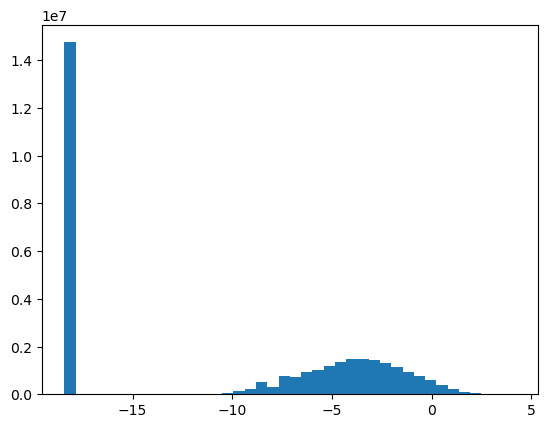

In [79]:
plt.hist(np.log(precip), bins=40)

In [29]:
precip = ds[-1].flatten()[::10]
# make precip positive
# lambda1 = abs(precip.min()) + 1.e-6
precip = precip + 1
precip_rescale, lambda2 = boxcox(precip)

In [20]:
precip_rescale = precip_rescale[precip_rescale>-50]

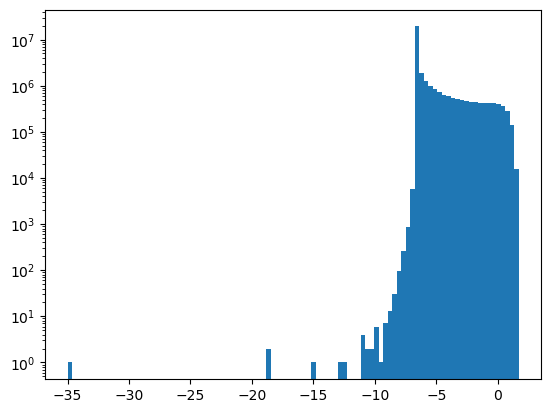

In [23]:
plt.hist(precip_rescale, bins=100)
plt.yscale('log')

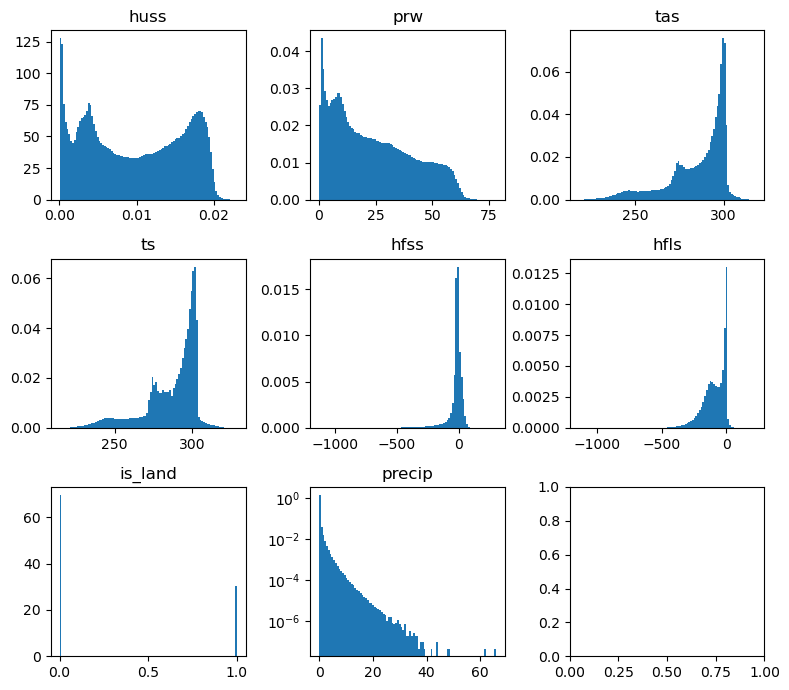

In [3]:
fig, axs = plt.subplots(3, 3, figsize=(8, 7))
axs = axs.flatten()
for i, var in enumerate(['huss', 'prw', 'tas', 'ts', 'hfss', 'hfls', 'is_land', 'precip']):
    axs[i].hist(ds[i,:, ::10].flatten(), bins=100, density=True)
    scale = 'log' if var=='precip' else 'linear'
    axs[i].set(title=var, yscale=scale)

plt.tight_layout()

In [8]:
P_scaled = np.log(1 + ds[-1])

In [11]:
P_rescaled = np.exp(P_scaled) - 1

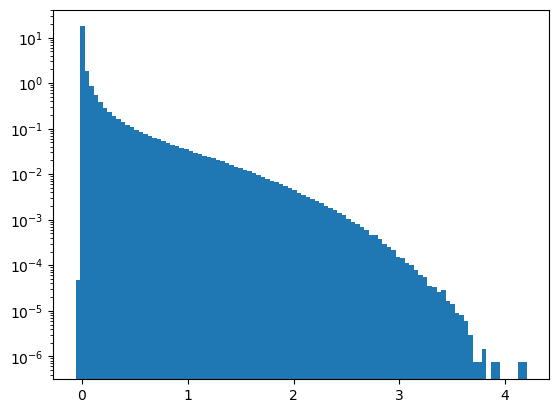

In [10]:
plt.hist(P_scaled.flatten()[::10], bins=100, density=True)
plt.yscale('log')

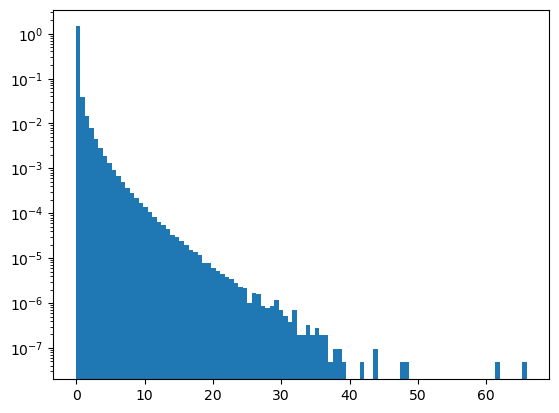

In [12]:
plt.hist(P_rescaled.flatten()[::10], bins=100, density=True)
plt.yscale('log')

In [2]:
ds_standardized = get_standardized_ds()

(8, 3897, 81920)


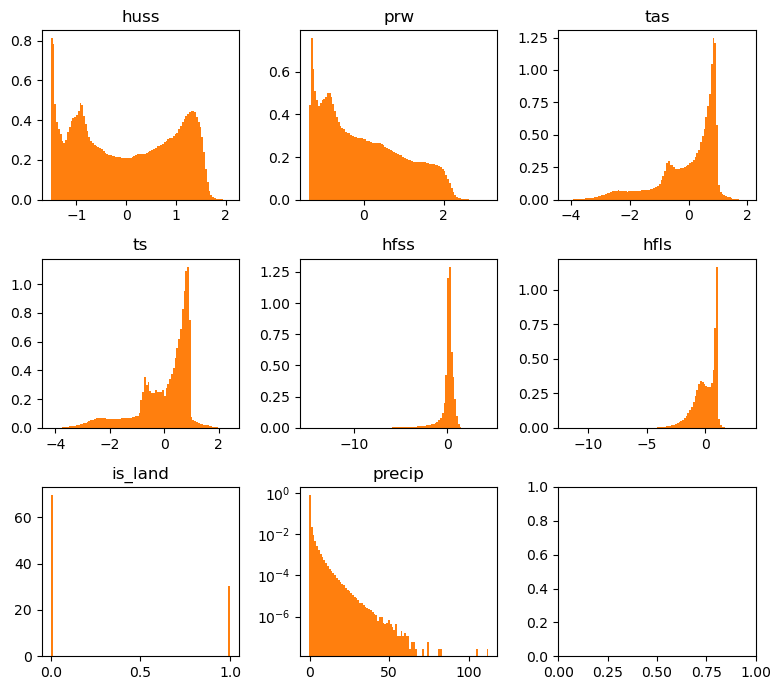

In [4]:
fig, axs = plt.subplots(3, 3, figsize=(8, 7))
axs = axs.flatten()
for i, var in enumerate(['huss', 'prw', 'tas', 'ts', 'hfss', 'hfls', 'is_land', 'precip']):
    axs[i].hist(ds_standardized[i,:, ::10].flatten(), bins=100, density=True, color='tab:orange')
    scale = 'log' if var=='precip' else 'linear'
    axs[i].set(title=var, yscale=scale)

plt.tight_layout()

In [9]:
mean = xr.load_dataarray('merged_DYAMOND_variable_mean.nc')
mean[-1] = 0.0
mean.to_netcdf('merged_DYAMOND_variable_mean.nc')

In [11]:
std = xr.load_dataarray('merged_DYAMOND_variable_std.nc')
std[-1] = 1.0
std.to_netcdf('merged_DYAMOND_variable_std.nc')

In [12]:
mean = xr.load_dataarray('merged_DYAMOND_variable_std.nc')
mean

<xarray.DataArray (variable: 8)> Size: 64B
array([6.36115391e-03, 1.74134502e+01, 1.64571209e+01, 1.73574276e+01,
       7.40477448e+01, 8.95874939e+01, 1.00000000e+00, 1.00000000e+00])
Coordinates:
  * variable  (variable) <U7 224B 'huss' 'prw' 'tas' ... 'is_land' 'precip'

In [60]:
import xarray as xr
rescale_factors.to_netcdf('merged_DYAMOND_variable_normalization_factor.nc')

In [23]:
ds_std.to_netcdf('merged_DYAMOND_variable_std.nc')

### Accuracy with respect to number of past timesteps

In [2]:
model_base = torch.load('networks/NNbase/n_features=6_memory_indices=None_latent_dims=0_past_timesteps=0/20251107135137_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_3 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=3/20251107200823_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_10 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=10/20251107204236_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)
model_20 = torch.load('networks/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=5_past_timesteps=20/20251108002837_global_oceanland_threshold=0.0_kernel=3_alpha=0.7_lr=0.001.pkl', weights_only=False, map_location=device)

In [4]:
model_base.R2

[0.528276801109314]

In [6]:
print(r'$\ell$')

$\ell$


0.36440160349319056
0.32479930202982105
0.3052922608771157


[Text(0.5, 0, 'epoch'),
 Text(0, 0.5, '$\\ell = 0.7 \\ell_{Precip} + 0.3 \\ell_{recon}$')]

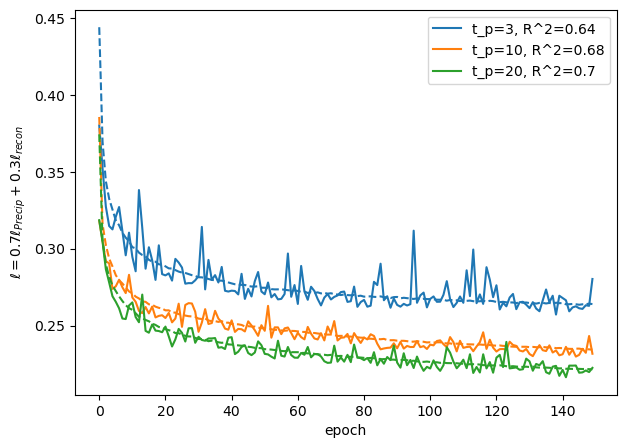

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(7,5))
for model, c in zip([model_3, model_10, model_20], ['tab:blue', 'tab:orange', 'tab:green']):
    plot_loss(model, label=f't_p={model.past_timesteps}, R^2={round(model.R2[0], 2)}', ax=ax, color=c)
ax.legend()
ax.set(xlabel='epoch', ylabel=r'$\ell = 0.7 \ell_{Precip} + 0.3 \ell_{recon}$')

### Make latent space variables for ODE learning

In [2]:
ds = get_standardized_ds('global', 'ocean')

past_timesteps = 10
latent_dims = 5
n_features = 6
kernel_size= 3
memory_indices = [0, 1, 2, 3, 4, 5]
trainloader, valloader, _ = get_dataloader(ds, share_train=.8, share_val=.1, batch_size=1)

(8, 3897, 54702)


In [3]:
from datetime import datetime

In [ ]:
ds = get_standardized_ds('global', 'ocean')

past_timesteps = 10
latent_dims = 5
n_features = 6
kernel_size= 3
memory_indices = [0, 1, 2, 3, 4, 5]
trainloader, valloader, _ = get_dataloader(ds, share_train=.8, share_val=.1, batch_size=1)

model_path = 'networks/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5, 6]_latent_dims=4_past_timesteps=50/20251127175237_global_ocean_threshold=0.05_kernel=3_alpha=0.7_lr=0.001_weigth_decay=0.0001.pkl'
model_10 = torch.load(model_path, weights_only=False, map_location=device)
model = model_10.to(device)
#print(model.R2)
model.X = ds 
model.X = model.X.to(device)
criterion = nn.MSELoss()

def make_Z_vars_for_ODE_learning(model, train_loader, val_loader):
    precip_threshold = 0.05  # Not implemented yet
    save_dir = Path(f'Z_data/{model.model_name}/n_features={model.n_features}_memory_indices={model.memory_indices}_latent_dims={model.latent_dims}_past_timesteps={model.past_timesteps}')
    if not save_dir.exists(): 
        os.makedirs(save_dir) 
    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")

    # Set preprocessing function
    if model.model_name in ['NN+AE+D', 'ConvNN+AE+D', 'NNbase']:
        if precip_threshold > 0.0:
            process_func = preprocess_thresholded
            process_args = (precip_threshold,)
        else:
            process_func = preprocess
            process_args = ()
    else:
        raise ValueError(f'No pre-processing function set for {model.model_name}')

    model.eval()
    XYZ_train = []
    with torch.no_grad():
        # Iterate over batches
        for coords in train_loader:
            # Preprocessing
            x_present, x_past, y = process_func(model.X, coords, model.past_timesteps, model.n_features, 
                                                train_loader.dataset.tstart, train_loader.dataset.tend,
                                                *process_args)  
            z = model.encoder(x_past)
            c = coords.to(device)
            c = torch.repeat_interleave(c, z.shape[0]).reshape(-1, 1)
            xyz = torch.cat([c, x_present, y, z], dim=-1).detach().cpu().numpy()
            # print(xyz.shape)
            XYZ_train.append(xyz)
    try:
        XYZ_train = np.array(XYZ_train)
        np.save(f'{save_dir}/{timestamp}_Ztrain_{model.model_name}_tp={model.past_timesteps}_wd={model.weight_decay}.npy', XYZ_train)
    except ValueError:
        XYZ_train = np.concatenate(XYZ_train, axis=0)
        np.save(f'{save_dir}/{timestamp}_Ztrain_{model.model_name}_tp={model.past_timesteps}_pr={precip_threshold}_wd={model.weight_decay}.npy', XYZ_train)

    XYZ_val = []
    with torch.no_grad():
        # Iterate over batches
        for coords in val_loader:
            # Preprocessing
            x_present, x_past, y = process_func(model.X, coords, model.past_timesteps, model.n_features, 
                                                val_loader.dataset.tstart, val_loader.dataset.tend, 
                                                *process_args)  
            z = model.encoder(x_past)
            c = coords.to(device)
            c = torch.repeat_interleave(c, z.shape[0]).reshape(-1, 1)
            xyz = torch.cat([c, x_present, y, z], dim=-1).detach().cpu().numpy()
            XYZ_val.append(xyz)
    
    try:
        XYZ_val = np.array(XYZ_val)
        np.save(f'{save_dir}/{timestamp}_Zval_{model.model_name}_tp={model.past_timesteps}_wd={model.weight_decay}.npy', XYZ_val)
    except ValueError:
        XYZ_val = np.concatenate(XYZ_val, axis=0)
        np.save(f'{save_dir}/{timestamp}_Zval_{model.model_name}_tp={model.past_timesteps}_pr={precip_threshold}_wd={model.weight_decay}.npy', XYZ_val)


make_Z_vars_for_ODE_learning(model_10, trainloader, valloader)

### EDA DYAMOND

In [9]:
import cartopy.crs as ccrs

In [10]:
ds = load_DYAMOND_data()
ds = ds[['huss', 'prw', 'tas', 'ts', 'hfss', 'hfls', 'is_land', 'precip']]

In [11]:
lon, lat = ds.clon.values, ds.clat.values

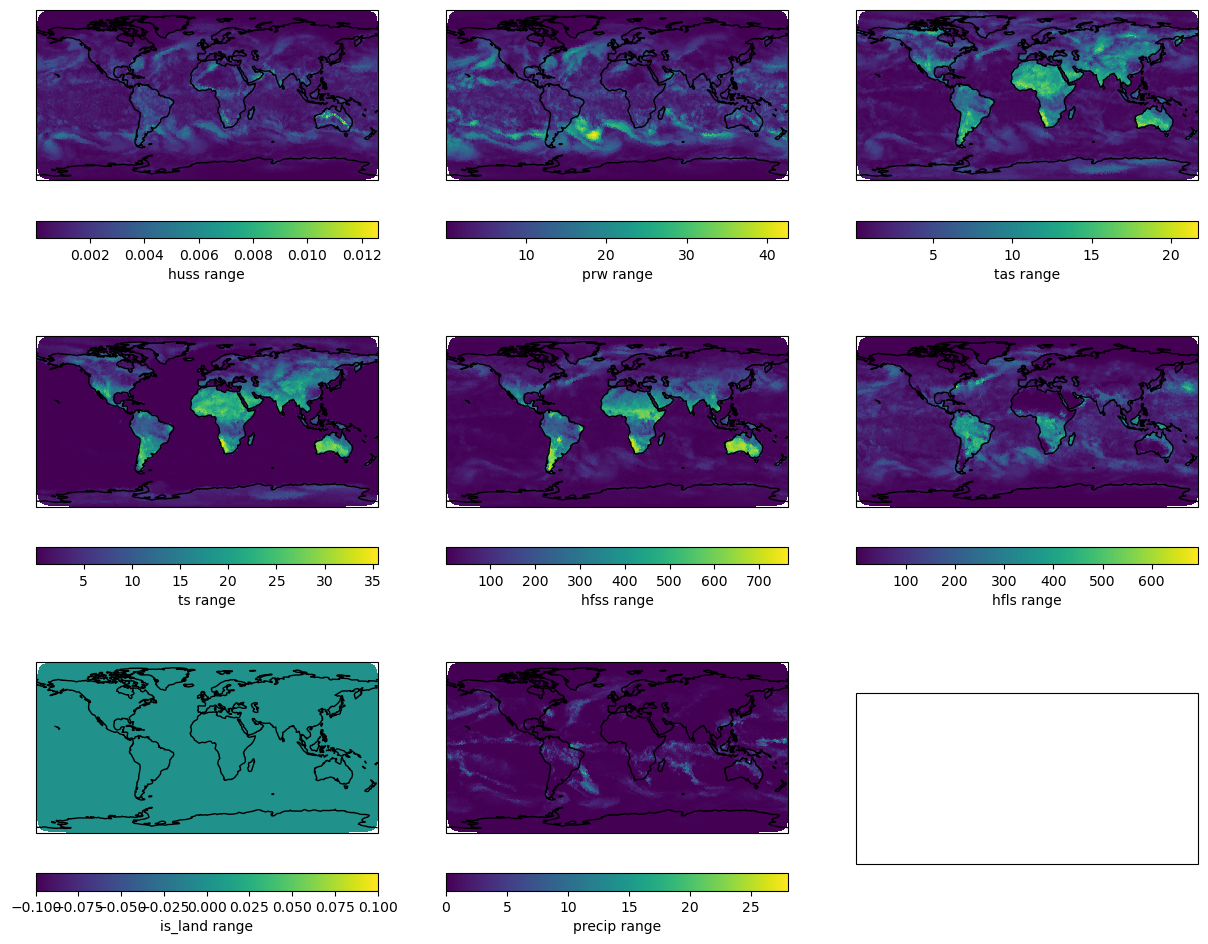

In [86]:
ds_tsclice = ds.isel({'time': slice(500, 600)})
fig, axs = plt.subplots(3, 3, subplot_kw={"projection": ccrs.PlateCarree()}, figsize=(15, 12))
axs = axs.flatten()
for ax, var in zip(axs, ['huss', 'prw', 'tas', 'ts', 'hfss', 'hfls', 'is_land', 'precip']):
    ts_range = abs(ds_tsclice[var].min(dim='time') - ds_tsclice[var].max(dim='time'))
    sc = ax.tripcolor(
        lon, lat, ts_range.values,
        transform=ccrs.PlateCarree(), cmap="viridis", vmax=None)
    ax.coastlines(resolution="110m", color="black", linewidth=1.0, zorder=10)
    fig.colorbar(sc, ax=ax, orientation="horizontal", label=f"{var} range")


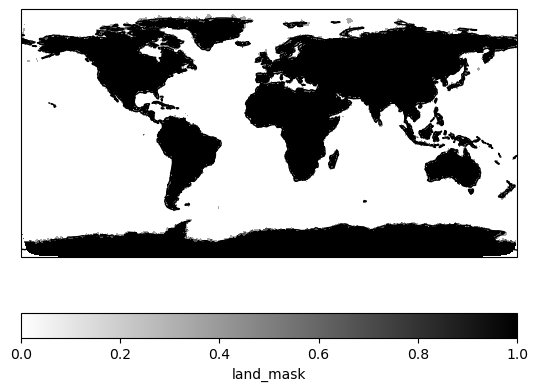

In [13]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
sc = ax.tripcolor(
    lon, lat, ds['is_land'].values[1000, :],
    transform=ccrs.PlateCarree(), cmap="binary", vmax=None
)

ax.coastlines(resolution="110m", color="black", linewidth=1.0, zorder=10)
fig.colorbar(sc, ax=ax, orientation="horizontal", label="land_mask")

In [129]:
coords_ocean = np.where(ds.is_land.isel({'time': 0}) == 0)[0]
coords_ocean

np.random.choice(coords_ocean, 9)

array([ 4480, 24704, 68065, 54999, 56443, 38640, 79625, 61066, 80292])

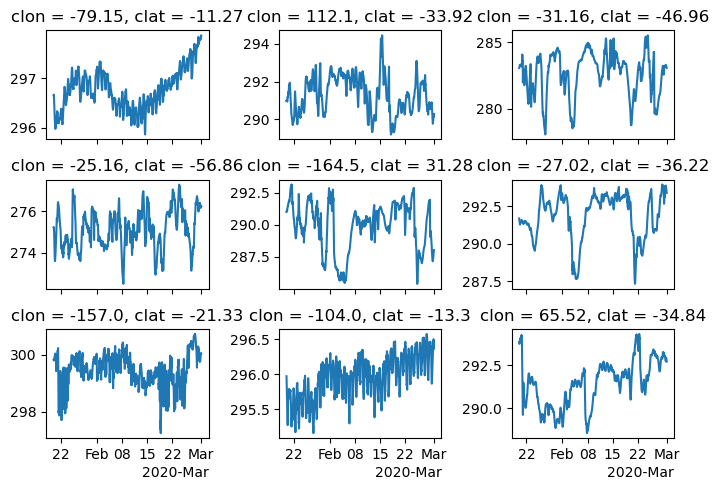

In [144]:
np.random.seed(6)
#coords = np.random.randint(0, 81290, size=9)
coords = np.random.choice(coords_ocean, 9)

fig, axs = plt.subplots(3, 3, figsize=(7, 5), sharex=True)
axs = axs.flatten()

for coord, ax in zip(coords, axs):
    tas = ds.tas.sel({'cell': [coord]}).plot(ax=ax)
    ax.set(ylabel=None, xlabel=None)
plt.tight_layout()

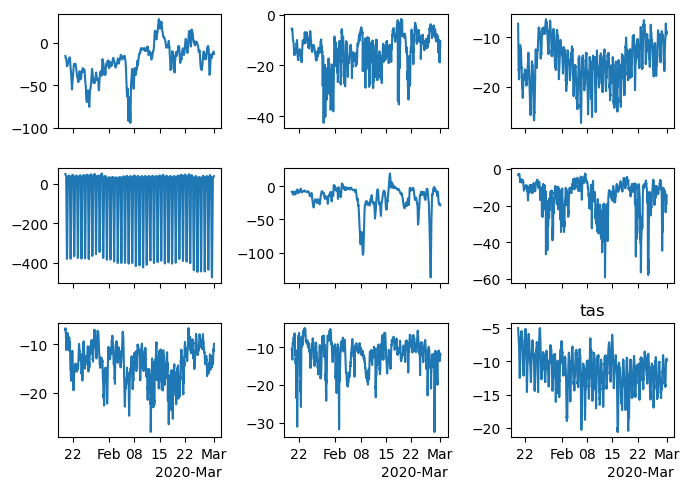

In [15]:
np.random.seed(2)
coords = np.random.randint(0, 81290, size=9)

fig, axs = plt.subplots(3, 3, figsize=(7, 5), sharex=True)
axs = axs.flatten()

for coord, ax in zip(coords, axs):
    tas = ds.hfss.sel({'cell': [coord]}).plot(ax=ax)
    ax.set(title=None, ylabel=None, xlabel=None)
plt.title('tas')
plt.tight_layout()

### EDA latent space variables

In [97]:
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=9_past_timesteps=50/20251118142222_Ztrain_ConvNN+AE+D_tp=50_wd=0.0001.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=9_past_timesteps=50/20251118142222_Zval_ConvNN+AE+D_tp=50_wd=0.0001.npy')
# XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=9_past_timesteps=50/20251118095429_Ztrain_ConvNN+AE+D_tp=50_wd=0.0001.npy')
# XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=6_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=9_past_timesteps=50/20251118095429_Zval_ConvNN+AE+D_tp=50_wd=0.0001.npy')

In [98]:
def get_z_for_coord(XZ, coord):
    ind = np.where(XZ_train[:, 0, 0] == float(coord))[0]
    return XZ[ind, :, 8:][0]

get_z_for_coord(XZ_train, 33508)

array([[ 0.2644835 ,  0.11911407, -2.5370038 , ..., -4.515119  ,
        -4.5101185 ,  0.39448097],
       [ 0.17943442,  0.12159211, -2.7644482 , ..., -4.5604057 ,
        -4.4512086 ,  0.39295304],
       [ 0.09023941,  0.1240561 , -2.996796  , ..., -4.593762  ,
        -4.380972  ,  0.3853727 ],
       ...,
       [ 0.23386532,  0.16597734, -4.080865  , ..., -6.998177  ,
        -3.9606457 ,  0.3006046 ],
       [ 0.18085709,  0.16362764, -4.307096  , ..., -6.8380184 ,
        -3.788131  ,  0.3203607 ],
       [ 0.13392329,  0.15974972, -4.5803385 , ..., -6.618738  ,
        -3.6127796 ,  0.3684558 ]], shape=(2107, 9), dtype=float32)

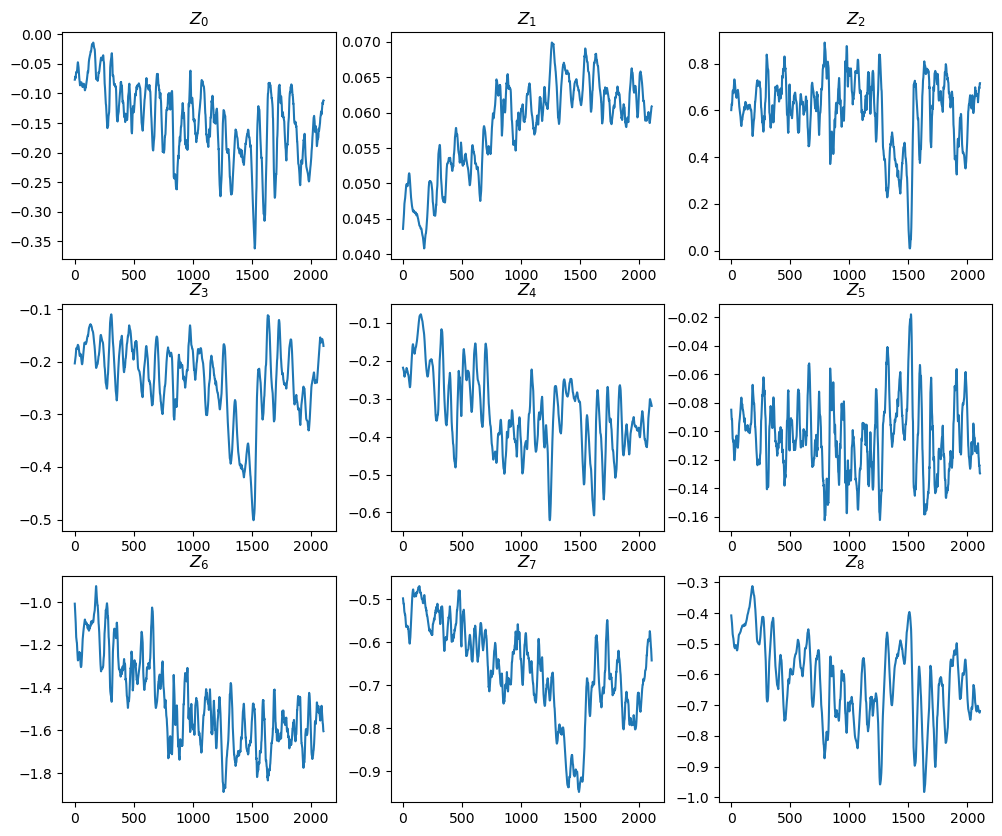

In [143]:
coord = 43127
 
z = get_z_for_coord(XZ_train, coord)
fig, axs = plt.subplots(3, 3, figsize=(12, 10))
axs = axs.flatten()
for i in range(9):
    axs[i].plot(z[:, i])
    axs[i].set(title=rf'$Z_{{{i}}}$')

(81920, 9)


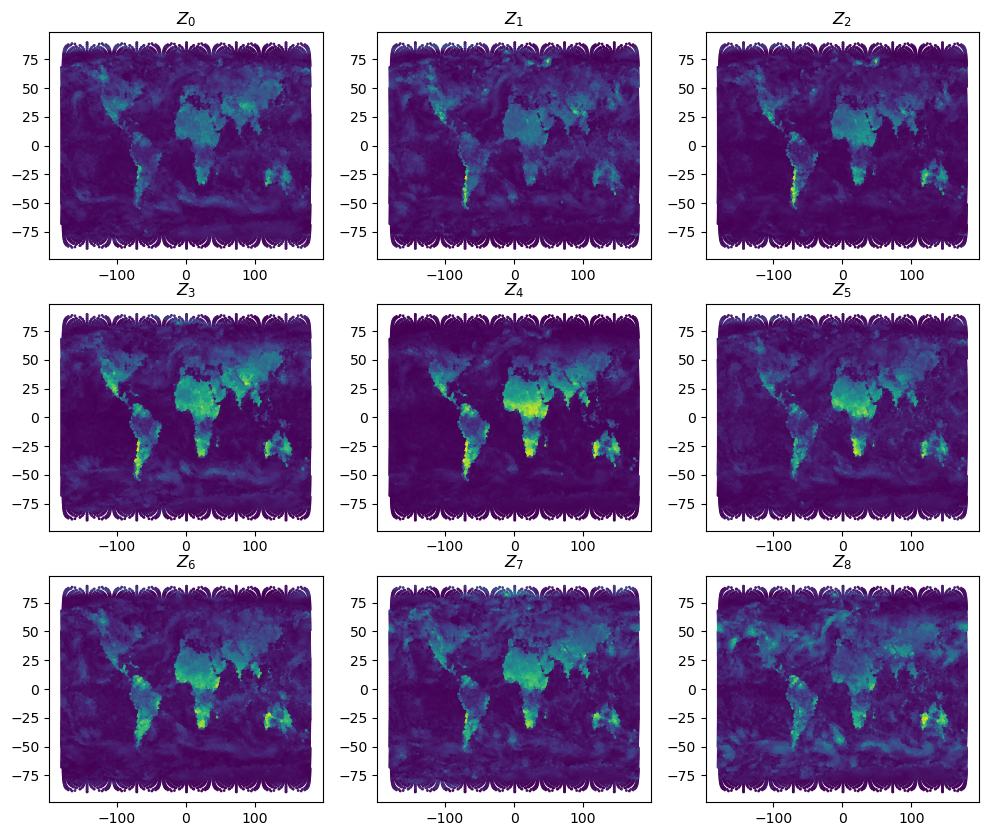

In [100]:
coords = XZ_train[:, 0, 0].astype(int)
Z = XZ_train[:, 500:600, 8:]
Z_range = np.absolute(np.min(Z, axis=1) - np.max(Z, axis=1))
print(Z_range.shape)
fig, axs = plt.subplots(3, 3, figsize=(12, 10))
axs = axs.flatten()
for i in range(9):
    axs[i].scatter(lon[coords], lat[coords], c=Z_range[:, i], s=1, cmap='viridis')
    axs[i].set(title=rf'$Z_{{{i}}}$')

np.float32(33597.0)